# Analyse des Tweets - Élection USA 2020
## Donald Trump vs Joe Biden

Ce notebook analyse les tweets contenant les hashtags relatifs aux deux candidats de l'élection présidentielle américaine de 2020.

## 1. Importation des bibliothèques

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration pour l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Chargement des données

⚠️ Les fichiers sont volumineux (~500MB et ~380MB). Chargement de l'**intégralité** des données (cela peut prendre plusieurs minutes).

In [4]:
# Chargement de l'intégralité des données avec gestion des erreurs
import csv
from datetime import datetime as dt
import os

def load_twitter_data(filename, max_rows=None):
    """Charge les données Twitter avec gestion robuste des erreurs"""
    if not os.path.exists(filename):
        print(f"ERREUR: Le fichier '{filename}' est introuvable.")
        print(f"Chemin actuel: {os.getcwd()}")
        print("\nAssurez-vous que les fichiers CSV sont dans le bon répertoire.")
        return None
    
    data = []
    skipped = 0
    start_time = dt.now()
    
    print(f"Chargement de {filename}...")
    
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        header = f.readline().strip().split(',')
        num_cols = len(header)
        
        for i, line in enumerate(f):
            if max_rows and len(data) >= max_rows:
                break
            
            if (i + 1) % 100000 == 0:
                elapsed = (dt.now() - start_time).total_seconds()
                print(f"   {len(data):,} tweets chargés ({skipped:,} ignorés)... ({elapsed:.1f}s)")
            
            try:
                reader = csv.reader([line], quotechar='"', delimiter=',', 
                                   quoting=csv.QUOTE_ALL, skipinitialspace=True)
                row = next(reader)
                
                if len(row) >= 5:
                    if len(row) < num_cols:
                        row.extend([None] * (num_cols - len(row)))
                    elif len(row) > num_cols:
                        row = row[:num_cols]
                    data.append(row)
                else:
                    skipped += 1
            except Exception as e:
                skipped += 1
                continue
    
    elapsed_total = (dt.now() - start_time).total_seconds()
    minutes = int(elapsed_total // 60)
    seconds = int(elapsed_total % 60)
    print(f"Chargé {len(data):,} lignes en {minutes}m {seconds}s, {skipped:,} lignes ignorées ({skipped/(len(data)+skipped)*100:.1f}% d'erreurs)")
    return pd.DataFrame(data, columns=header)

print("="*70)
print("CHARGEMENT COMPLET DES DONNÉES")
print("="*70)

df_trump = load_twitter_data('data/hashtag_donaldtrump.csv', max_rows=None)
if df_trump is None:
    print("\nImpossible de continuer sans les fichiers de données.")
    print("Placez 'hashtag_donaldtrump.csv' et 'hashtag_joebiden.csv' dans le dossier 'data/'.")
    print(f"  {os.path.join(os.getcwd(), 'data')}")
else:
    df_trump['candidat'] = 'Trump'

    df_biden = load_twitter_data('data/hashtag_joebiden.csv', max_rows=None)
    if df_biden is not None:
        df_biden['candidat'] = 'Biden'

        print("\nConversion des colonnes numériques...")
        numeric_cols = ['likes', 'retweet_count', 'user_followers_count']
        for col in numeric_cols:
            if col in df_trump.columns:
                df_trump[col] = pd.to_numeric(df_trump[col], errors='coerce').fillna(0)
                df_biden[col] = pd.to_numeric(df_biden[col], errors='coerce').fillna(0)

        print("\n" + "="*70)
        print("DONNÉES CHARGÉES")
        print("="*70)
        print(f"Trump: {len(df_trump):,} tweets ({len(df_trump)/2315714*100:.1f}% du total)")
        print(f"Biden: {len(df_biden):,} tweets ({len(df_biden)/1817206*100:.1f}% du total)")
        print(f"TOTAL: {len(df_trump) + len(df_biden):,} tweets")
        print("="*70)

CHARGEMENT COMPLET DES DONNÉES
Chargement de data/hashtag_donaldtrump.csv...
   40,403 tweets chargés (59,596 ignorés)... (0.9s)
   80,269 tweets chargés (119,730 ignorés)... (1.6s)
   120,005 tweets chargés (179,994 ignorés)... (2.5s)
   159,566 tweets chargés (240,433 ignorés)... (3.3s)
   203,799 tweets chargés (296,200 ignorés)... (4.4s)
   245,375 tweets chargés (354,624 ignorés)... (5.2s)
   285,591 tweets chargés (414,408 ignorés)... (6.0s)
   325,861 tweets chargés (474,138 ignorés)... (7.2s)
   366,835 tweets chargés (533,164 ignorés)... (8.1s)
   407,436 tweets chargés (592,563 ignorés)... (8.8s)
   447,912 tweets chargés (652,087 ignorés)... (9.6s)
   489,980 tweets chargés (710,019 ignorés)... (10.9s)
   530,574 tweets chargés (769,425 ignorés)... (11.7s)
   569,725 tweets chargés (830,274 ignorés)... (12.5s)
   609,722 tweets chargés (890,277 ignorés)... (13.3s)
   649,194 tweets chargés (950,805 ignorés)... (14.0s)
   690,584 tweets chargés (1,009,415 ignorés)... (15.4s)


## 3. Exploration des données

In [5]:
# Aperçu des données Trump
print("=" * 50)
print("DONNÉES TRUMP")
print("=" * 50)
print("\nPremières lignes:")
display(df_trump.head())
print("\nInformations:")
print(df_trump.info())
print("\nStatistiques descriptives:")
display(df_trump.describe())

DONNÉES TRUMP

Premières lignes:


,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,user_join_date,user_followers_count,user_location,lat,long,city,country,continent,state,state_code,collected_at,candidat
0,#ElSolLatino #yobrilloconelsol https://t.co/6F...,0.0,0.0,0.0,3.606665e+08,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,None,None,None,0.000000e+00,None,None,None,None,None,None,None,None,None,Trump
1,"⠀🌅 Miami: /elsollatinonewsmiami""",2011-08-23 15:33:45,1860.0,0.0,2.577427e+01,-80.19366,,United States of America,North America,Florida,FL,0.000000e+00,None,None,None,None,None,None,None,None,None,Trump
2,2020-10-15 00:00:01,1.3165292227484303e+18,"Usa 2020, Trump contro Facebook e Twitter: cop...",26.0,9.000000e+00,Social Mediaset,331617619.0,Tgcom24,MediasetTgcom24,Profilo ufficiale di Tgcom24: tutte le notizie...,2011-07-08 13:12:20,1.067661e+06,,,,,,,,,2020-10-21 00:00:00.373216530,Trump
3,"Um. What?""",2.0,1.0,0.0,8.436472e+06,snarke,snarke,"Will mock for food! Freelance writer, blogger,...",2007-08-26 05:56:11,1185.0,Portland,4.552025e+01,-122.6741949,Portland,United States of America,North America,Oregon,OR,2020-10-21 00:00:00.746433060,None,None,Trump
4,2020-10-15 00:00:02,1.316529227471237e+18,2 hours since last tweet from #Trump! Maybe he...,0.0,0.000000e+00,Trumpytweeter,8.28355589206057e+17,Trumpytweeter,trumpytweeter,"If he doesn't tweet for some time, should we b...",2017-02-05 21:32:17,3.200000e+01,,,,,,,,,2020-10-21 00:00:01.119649591,Trump



Informations:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1142104 entries, 0 to 1142103
Data columns (total 22 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   created_at            1142104 non-null  object 
 1   tweet_id              1142104 non-null  object 
 2   tweet                 1142104 non-null  object 
 3   likes                 1142104 non-null  float64
 4   retweet_count         1142104 non-null  float64
 5   source                1140568 non-null  object 
 6   user_id               1140024 non-null  object 
 7   user_name             1139758 non-null  object 
 8   user_screen_name      1040228 non-null  object 
 9   user_description      1035283 non-null  object 
 10  user_join_date        971662 non-null   object 
 11  user_followers_count  1142104 non-null  float64
 12  user_location         824442 non-null   object 
 13  lat                   810597 non-null   object 
 14  long               

,likes,retweet_count,user_followers_count
count,1142104.0,1.142104e+06,1.142104e+06
mean,inf,1.708851e+17,2.329320e+13
std,NaN,4.064326e+17,5.223596e+15
min,0.0,-1.182428e+02,-1.187560e+02
25%,0.0,0.000000e+00,0.000000e+00
50%,0.0,0.000000e+00,9.000000e+00
75%,0.0,3.139465e+08,2.210000e+02
max,inf,1.325581e+18,1.312898e+18


In [6]:
# Aperçu des données Biden
print("=" * 50)
print("DONNÉES BIDEN")
print("=" * 50)
print("\nPremières lignes:")
display(df_biden.head())
print("\nInformations:")
print(df_biden.info())
print("\nStatistiques descriptives:")
display(df_biden.describe())

DONNÉES BIDEN

Premières lignes:


,created_at,tweet_id,tweet,likes,retweet_count,source,user_id,user_name,user_screen_name,user_description,user_join_date,user_followers_count,user_location,lat,long,city,country,continent,state,state_code,collected_at,candidat
0,#ElSolLatino #yobrilloconelsol https://t.co/6F...,0.0,0.0,0.0,3.606665e+08,El Sol Latino News,elsollatinonews,🌐 Noticias de interés para latinos de la costa...,None,None,None,0.000000,None,None,None,None,None,None,None,None,None,Biden
1,"⠀🌅 Miami: /elsollatinonewsmiami""",2011-08-23 15:33:45,1860.0,0.0,2.577427e+01,-80.19366,,United States of America,North America,Florida,FL,0.000000,None,None,None,None,None,None,None,None,None,Biden
2,2020-10-15 00:00:18,1.31652929585929e+18,#HunterBiden #HunterBidenEmails #JoeBiden #Joe...,0.0,0.000000e+00,Twitter for iPad,809904438.0,Cheri A. 🇺🇸,Biloximeemaw,"Locked and loaded Meemaw. Love God, my family ...",2012-09-08 01:03:57,6628.000000,,,,,,,,,2020-10-21 00:00:00.517827283,Biden
3,"https://t.co/uBqAFU86Ip""",0.0,0.0,0.0,3.494182e+09,Flag Waver,Flag_Wavers,,2015-08-30 19:38:21,1536.0,Golden Valley Arizona,46.304036,-109.17143119999999,,United States of America,North America,Montana,MT,2020-10-21 00:00:01.035654566,None,None,Biden
4,2020-10-15 00:00:21,1.3165293080815575e+18,@chrislongview Watching and setting dvr. Let’s...,0.0,0.000000e+00,Twitter for iPhone,8.242596012018524e+17,Michelle Ferg,MichelleFerg4,,2017-01-25 14:16:17,27.000000,,,,,,,,,2020-10-21 00:00:01.553481849,Biden



Informations:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 910594 entries, 0 to 910593
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   created_at            910594 non-null  object 
 1   tweet_id              910594 non-null  object 
 2   tweet                 910594 non-null  object 
 3   likes                 910594 non-null  float64
 4   retweet_count         910594 non-null  float64
 5   source                909348 non-null  object 
 6   user_id               908990 non-null  object 
 7   user_name             908783 non-null  object 
 8   user_screen_name      831052 non-null  object 
 9   user_description      827689 non-null  object 
 10  user_join_date        777340 non-null  object 
 11  user_followers_count  910594 non-null  float64
 12  user_location         661976 non-null  object 
 13  lat                   651798 non-null  object 
 14  long                  648336 non-null

,likes,retweet_count,user_followers_count
count,910594.0,9.105940e+05,9.105940e+05
mean,inf,1.703520e+17,2.096653e+13
std,NaN,4.057964e+17,4.908795e+15
min,0.0,-8.245844e+01,-1.187560e+02
25%,0.0,0.000000e+00,0.000000e+00
50%,0.0,0.000000e+00,1.200000e+01
75%,0.0,3.294859e+08,2.220000e+02
max,inf,1.325564e+18,1.294556e+18


In [7]:
# Vérification des valeurs manquantes
print("Valeurs manquantes - Trump:")
print(df_trump.isnull().sum())
print("\nValeurs manquantes - Biden:")
print(df_biden.isnull().sum())

Valeurs manquantes - Trump:
created_at                   0
tweet_id                     0
tweet                        0
likes                        0
retweet_count                0
source                    1536
user_id                   2080
user_name                 2346
user_screen_name        101876
user_description        106821
user_join_date          170442
user_followers_count         0
user_location           317662
lat                     331507
long                    335962
city                    337707
country                 338642
continent               339137
state                   339290
state_code              628668
collected_at            643361
candidat                     0
dtype: int64

Valeurs manquantes - Biden:
created_at                   0
tweet_id                     0
tweet                        0
likes                        0
retweet_count                0
source                    1246
user_id                   1604
user_name                 1811


## 4. Nettoyage et préparation des données

In [8]:
# Conversion des dates avec gestion des erreurs
df_trump['created_at'] = pd.to_datetime(df_trump['created_at'], errors='coerce')
df_biden['created_at'] = pd.to_datetime(df_biden['created_at'], errors='coerce')

# Supprimer les lignes avec des dates invalides
print(f"Tweets Trump avant nettoyage: {len(df_trump)}")
df_trump = df_trump.dropna(subset=['created_at'])
print(f"Tweets Trump après nettoyage: {len(df_trump)}")

print(f"Tweets Biden avant nettoyage: {len(df_biden)}")
df_biden = df_biden.dropna(subset=['created_at'])
print(f"Tweets Biden après nettoyage: {len(df_biden)}")

# Tri par date
df_trump = df_trump.sort_values('created_at')
df_biden = df_biden.sort_values('created_at')

# Extraction de nouvelles colonnes temporelles
for df in [df_trump, df_biden]:
    df['date'] = df['created_at'].dt.date
    df['hour'] = df['created_at'].dt.hour
    df['day_of_week'] = df['created_at'].dt.day_name()
    df['month'] = df['created_at'].dt.month

print("\n✅ Dates converties et nouvelles colonnes créées")

Tweets Trump avant nettoyage: 1142104
Tweets Trump après nettoyage: 553759
Tweets Biden avant nettoyage: 910594
Tweets Biden après nettoyage: 446328

✅ Dates converties et nouvelles colonnes créées


## 5. Analyses statistiques comparatives

In [9]:
# Combiner les données pour une analyse comparative
df_combined = pd.concat([df_trump, df_biden], ignore_index=True)

# Statistiques par candidat
print("\n" + "="*60)
print("STATISTIQUES COMPARATIVES")
print("="*60)

stats_comparison = df_combined.groupby('candidat').agg({
    'likes': ['mean', 'median', 'sum', 'max'],
    'retweet_count': ['mean', 'median', 'sum', 'max'],
    'user_followers_count': ['mean', 'median'],
    'tweet_id': 'count'
}).round(2)

stats_comparison.columns = ['_'.join(col).strip() for col in stats_comparison.columns.values]
display(stats_comparison)


STATISTIQUES COMPARATIVES


,likes_mean,likes_median,likes_sum,likes_max,retweet_count_mean,retweet_count_median,retweet_count_sum,retweet_count_max,user_followers_count_mean,user_followers_count_median,tweet_id_count
candidat,,,,,,,,,,,
Biden,10.15,0.0,4532368.0,165702.0,2.00,0.0,891187.0,63473.0,14453.02,232.0,446328
Trump,6.37,0.0,3526917.0,25987.0,1.31,0.0,727474.0,8731.0,12212.87,237.0,553759


## 6. Visualisations

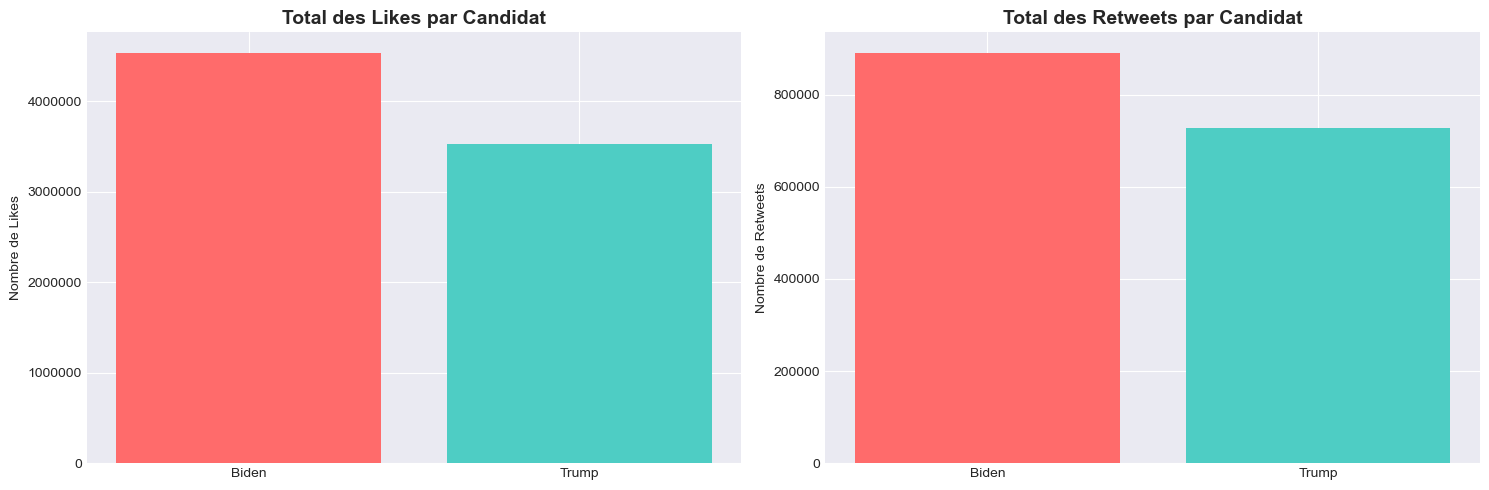

In [10]:
# Graphique 1: Comparaison du nombre total de likes et retweets
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Likes
likes_data = df_combined.groupby('candidat')['likes'].sum()
axes[0].bar(likes_data.index, likes_data.values, color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Total des Likes par Candidat', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de Likes')
axes[0].ticklabel_format(style='plain', axis='y')

# Retweets
retweets_data = df_combined.groupby('candidat')['retweet_count'].sum()
axes[1].bar(retweets_data.index, retweets_data.values, color=['#FF6B6B', '#4ECDC4'])
axes[1].set_title('Total des Retweets par Candidat', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nombre de Retweets')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

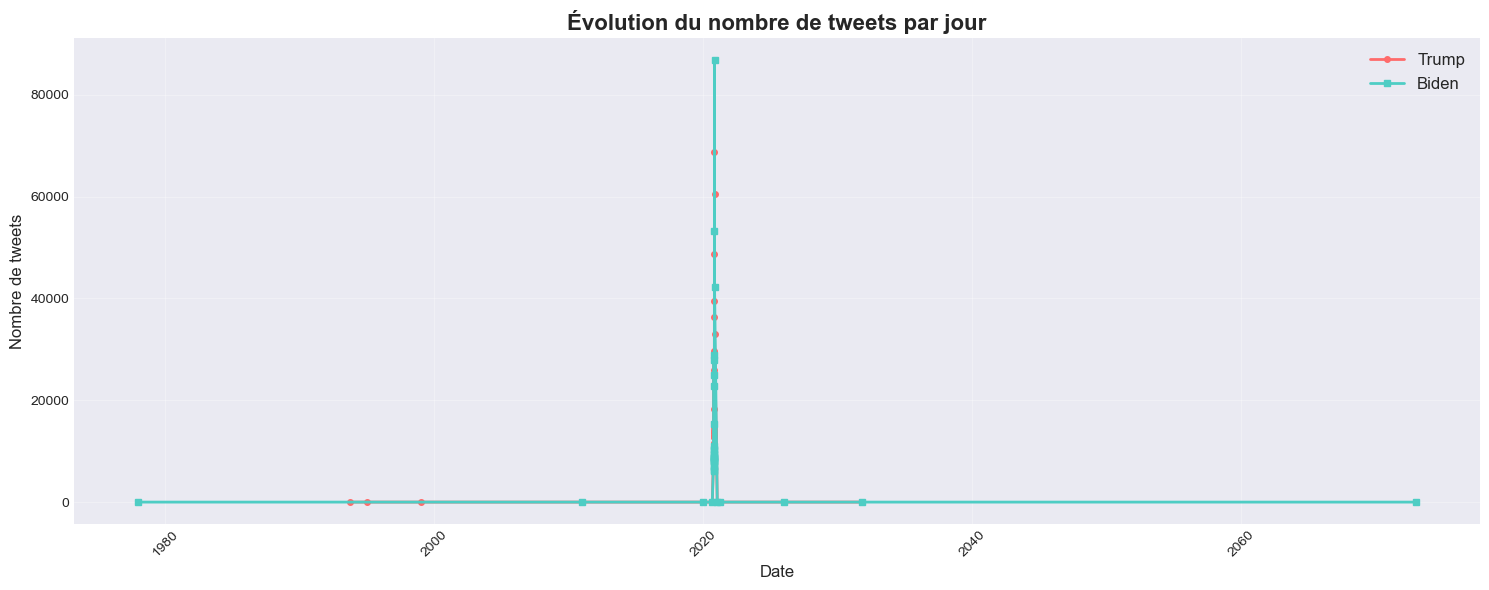

In [11]:
# Graphique 2: Évolution temporelle des tweets
fig, ax = plt.subplots(figsize=(15, 6))

tweets_by_date_trump = df_trump.groupby('date').size()
tweets_by_date_biden = df_biden.groupby('date').size()

ax.plot(tweets_by_date_trump.index, tweets_by_date_trump.values, 
        label='Trump', color='#FF6B6B', linewidth=2, marker='o', markersize=4)
ax.plot(tweets_by_date_biden.index, tweets_by_date_biden.values, 
        label='Biden', color='#4ECDC4', linewidth=2, marker='s', markersize=4)

ax.set_title('Évolution du nombre de tweets par jour', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Nombre de tweets', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

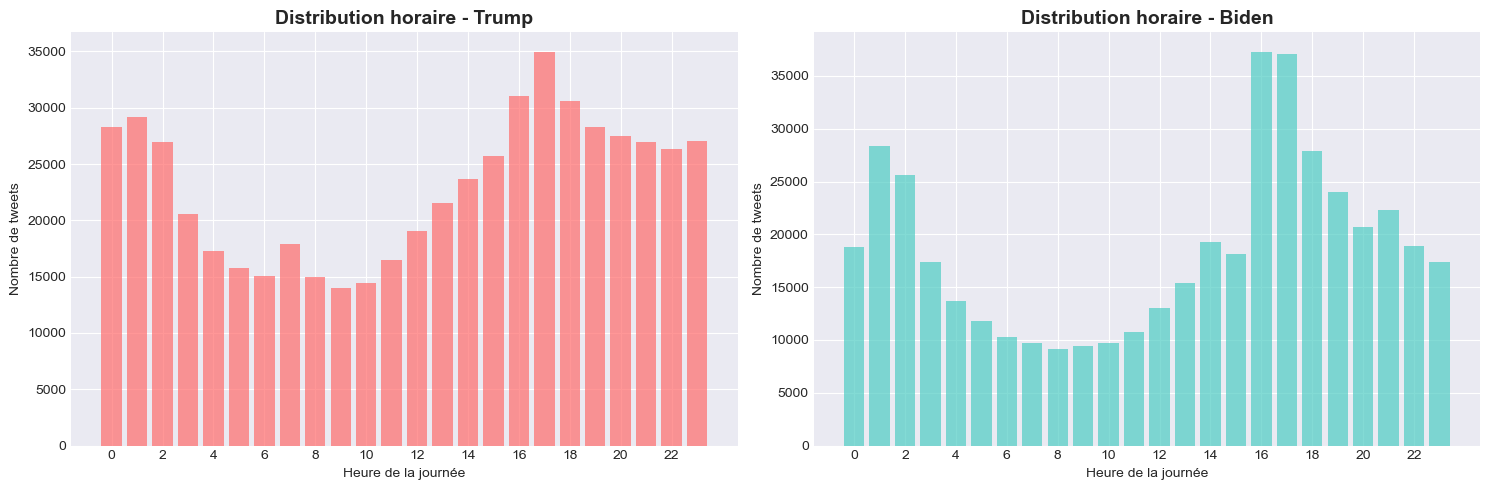

In [12]:
# Graphique 3: Distribution des tweets par heure de la journée
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Trump
hour_dist_trump = df_trump.groupby('hour').size()
axes[0].bar(hour_dist_trump.index, hour_dist_trump.values, color='#FF6B6B', alpha=0.7)
axes[0].set_title('Distribution horaire - Trump', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Nombre de tweets')
axes[0].set_xticks(range(0, 24, 2))

# Biden
hour_dist_biden = df_biden.groupby('hour').size()
axes[1].bar(hour_dist_biden.index, hour_dist_biden.values, color='#4ECDC4', alpha=0.7)
axes[1].set_title('Distribution horaire - Biden', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_ylabel('Nombre de tweets')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

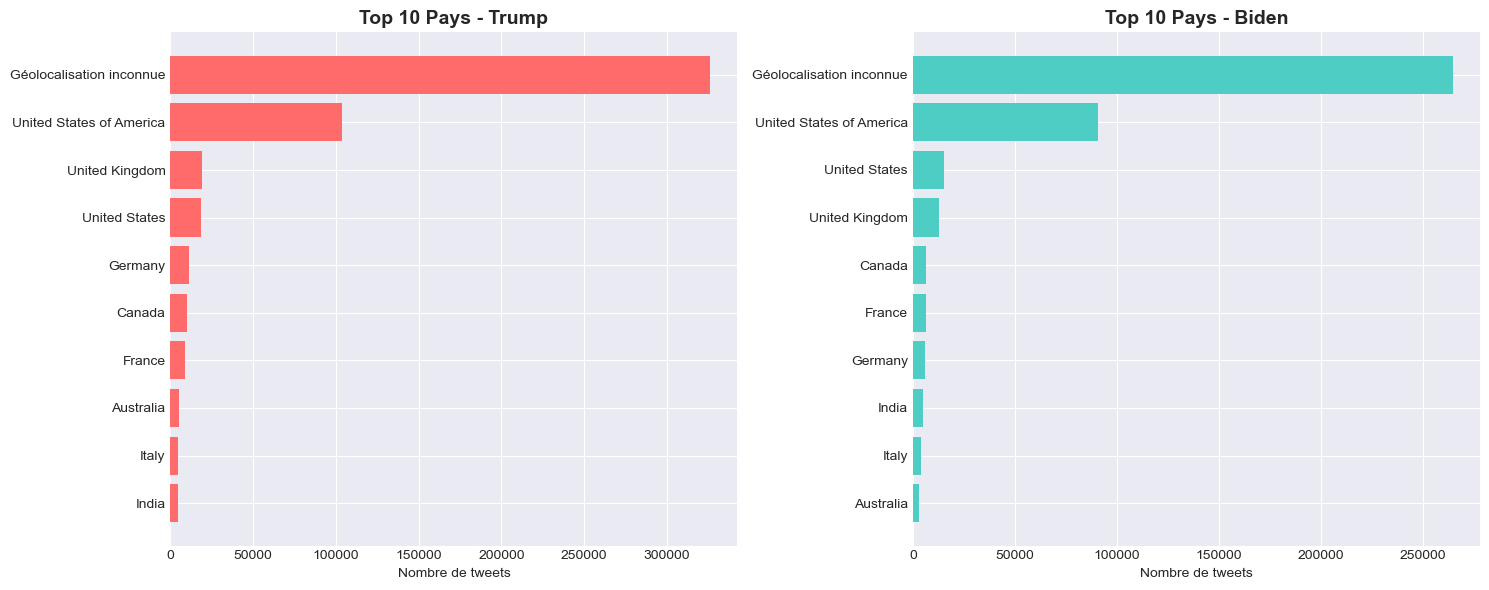

In [13]:
# Graphique 4: Top 10 des pays avec le plus de tweets
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Trump
# Remplacer les valeurs vides ou NaN par "Géolocalisation inconnue"
trump_countries = df_trump['country'].fillna('Géolocalisation inconnue')
trump_countries = trump_countries.replace('', 'Géolocalisation inconnue')
top_countries_trump = trump_countries.value_counts().head(10)

axes[0].barh(range(len(top_countries_trump)), top_countries_trump.values, color='#FF6B6B')
axes[0].set_yticks(range(len(top_countries_trump)))
axes[0].set_yticklabels(top_countries_trump.index)
axes[0].set_title('Top 10 Pays - Trump', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre de tweets')
axes[0].invert_yaxis()

# Biden
# Remplacer les valeurs vides ou NaN par "Géolocalisation inconnue"
biden_countries = df_biden['country'].fillna('Géolocalisation inconnue')
biden_countries = biden_countries.replace('', 'Géolocalisation inconnue')
top_countries_biden = biden_countries.value_counts().head(10)

axes[1].barh(range(len(top_countries_biden)), top_countries_biden.values, color='#4ECDC4')
axes[1].set_yticks(range(len(top_countries_biden)))
axes[1].set_yticklabels(top_countries_biden.index)
axes[1].set_title('Top 10 Pays - Biden', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de tweets')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

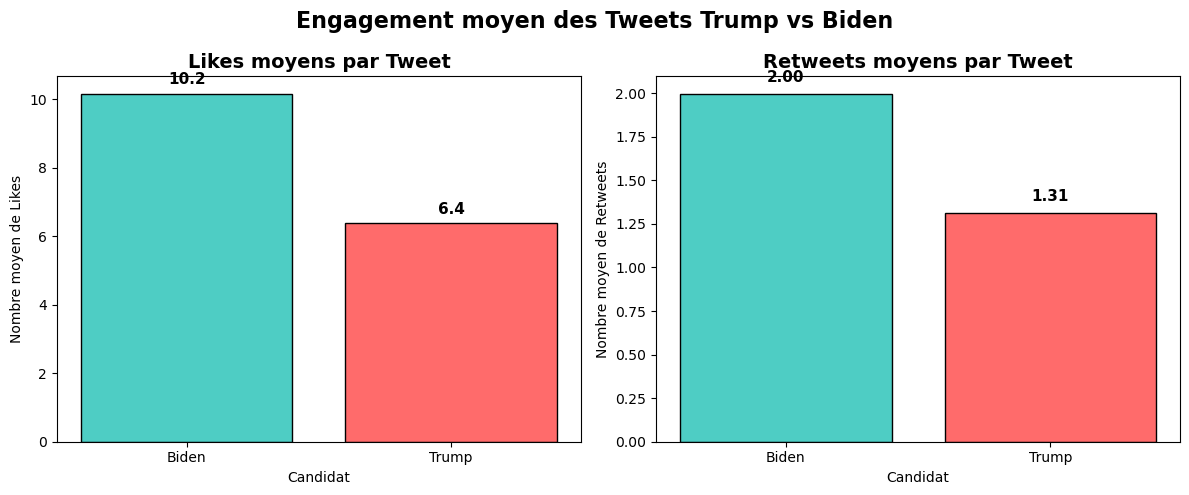


📊 Note : La médiane est de 0 pour les deux candidats car la majorité des tweets n'ont aucun like/retweet.


In [42]:
# Graphique 5: Comparaison des Likes et Retweets moyens par candidat
if 'df_combined' not in globals():
    print("Données combinées introuvables. Exécutez les cellules de préparation (fusion Trump/Biden) avant cette visualisation.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Calcul des moyennes
    stats_likes = df_combined.groupby('candidat')['likes'].mean()
    stats_retweets = df_combined.groupby('candidat')['retweet_count'].mean()
    
    # Couleurs par candidat
    colors = {'Trump': '#FF6B6B', 'Biden': '#4ECDC4'}
    bar_colors = [colors.get(c, '#888888') for c in stats_likes.index]
    
    # Graphique Likes
    bars1 = axes[0].bar(stats_likes.index, stats_likes.values, color=bar_colors, edgecolor='black')
    axes[0].set_title('Likes moyens par Tweet', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Nombre moyen de Likes')
    axes[0].set_xlabel('Candidat')
    
    for bar in bars1:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
                     f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Graphique Retweets
    bars2 = axes[1].bar(stats_retweets.index, stats_retweets.values, color=bar_colors, edgecolor='black')
    axes[1].set_title('Retweets moyens par Tweet', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Nombre moyen de Retweets')
    axes[1].set_xlabel('Candidat')
    
    for bar in bars2:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                     f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.suptitle('Engagement moyen des Tweets Trump vs Biden', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Info complémentaire
    print("\n📊 Note : La médiane est de 0 pour les deux candidats car la majorité des tweets n'ont aucun like/retweet.")

## 7. Analyse des sources de tweets

Top 10 des sources - Trump:
source
Twitter for iPhone                 29024
Twitter Web App                    19393
Twitter for Android                 8640
Twitter for iPad                    3067
TweetDeck                            517
NewsBot247                           516
dlvr.it                              506
Instagram                            453
Hootsuite Inc.                       333
In-House App for rgovconsulting      288
Name: count, dtype: int64

Top 10 des sources - Biden:
source
Twitter for iPhone                 22087
Twitter Web App                    12157
Twitter for Android                 5755
Twitter for iPad                    3035
Instagram                            315
TweetDeck                            270
Buffer                               261
Hootsuite Inc.                       217
In-House App for rgovconsulting      121
dlvr.it                              113
Name: count, dtype: int64


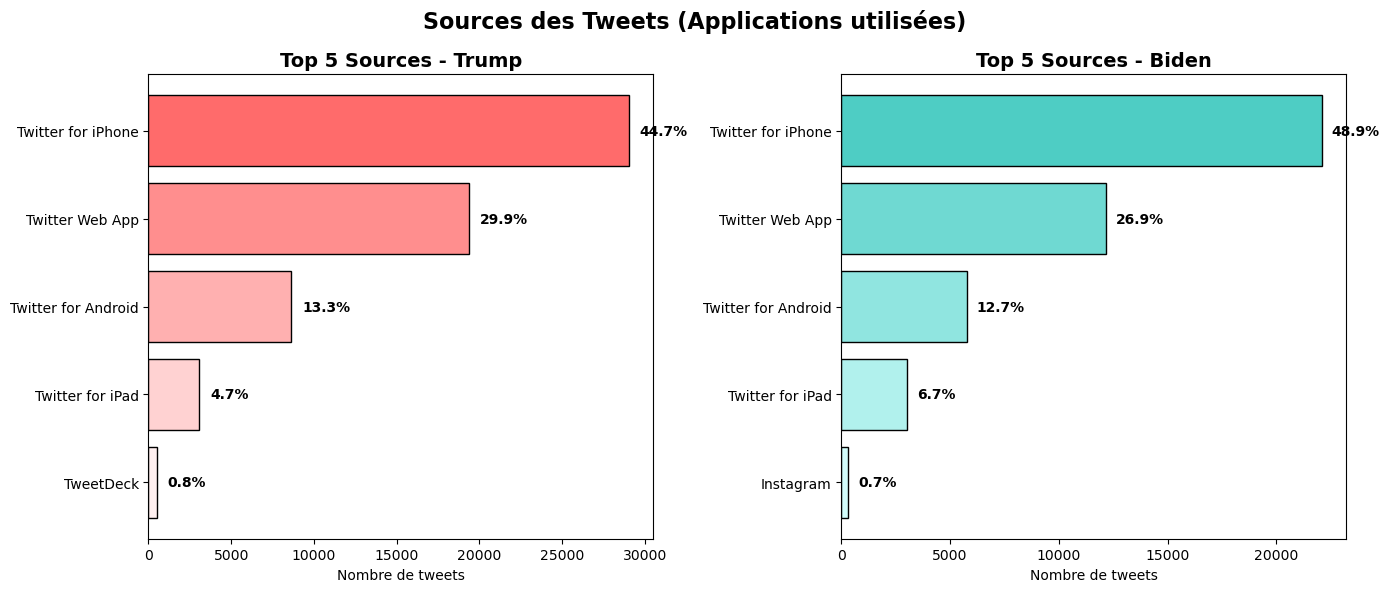

In [43]:
# Top sources de tweets
print("Top 10 des sources - Trump:")
print(df_trump['source'].value_counts().head(10))
print("\nTop 10 des sources - Biden:")
print(df_biden['source'].value_counts().head(10))

# Visualisation avec barres horizontales (plus lisible que les pie charts)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trump - Top 5 sources
top_sources_trump = df_trump['source'].value_counts().head(5)
colors_trump = ['#FF6B6B', '#FF8E8E', '#FFB0B0', '#FFD2D2', '#FFF0F0']
bars1 = axes[0].barh(range(len(top_sources_trump)), top_sources_trump.values, color=colors_trump, edgecolor='black')
axes[0].set_yticks(range(len(top_sources_trump)))
axes[0].set_yticklabels(top_sources_trump.index, fontsize=10)
axes[0].set_title('Top 5 Sources - Trump', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre de tweets')
axes[0].invert_yaxis()

# Ajouter les pourcentages
total_trump = df_trump['source'].count()
for i, (bar, val) in enumerate(zip(bars1, top_sources_trump.values)):
    pct = val / total_trump * 100
    axes[0].text(bar.get_width() + total_trump*0.01, bar.get_y() + bar.get_height()/2, 
                 f'{pct:.1f}%', va='center', fontsize=10, fontweight='bold')

# Biden - Top 5 sources
top_sources_biden = df_biden['source'].value_counts().head(5)
colors_biden = ['#4ECDC4', '#6FD9D2', '#90E5E0', '#B1F1ED', '#D2FDFB']
bars2 = axes[1].barh(range(len(top_sources_biden)), top_sources_biden.values, color=colors_biden, edgecolor='black')
axes[1].set_yticks(range(len(top_sources_biden)))
axes[1].set_yticklabels(top_sources_biden.index, fontsize=10)
axes[1].set_title('Top 5 Sources - Biden', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de tweets')
axes[1].invert_yaxis()

# Ajouter les pourcentages
total_biden = df_biden['source'].count()
for i, (bar, val) in enumerate(zip(bars2, top_sources_biden.values)):
    pct = val / total_biden * 100
    axes[1].text(bar.get_width() + total_biden*0.01, bar.get_y() + bar.get_height()/2, 
                 f'{pct:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Sources des Tweets (Applications utilisées)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Analyse des utilisateurs les plus actifs

In [16]:
# Top utilisateurs par nombre de tweets
print("Top 10 utilisateurs les plus actifs - Trump:")
top_users_trump = df_trump['user_screen_name'].value_counts().head(10)
print(top_users_trump)

print("\nTop 10 utilisateurs les plus actifs - Biden:")
top_users_biden = df_biden['user_screen_name'].value_counts().head(10)
print(top_users_biden)

Top 10 utilisateurs les plus actifs - Trump:
user_screen_name
robinsnewswire    1325
Hotpage_News       921
THCPetDoctor       911
POTUSNetwork       709
2020Vision6        702
bitcoinconnect     688
lookforsun         545
thejoshuablog      530
PulpNews           523
DavidFDodge1       512
Name: count, dtype: int64

Top 10 utilisateurs les plus actifs - Biden:
user_screen_name
steveziegenbus2    1256
Hotpage_News        922
Oxforduk23          552
tismdude            442
realphannigan       407
TrentU23947054      398
DemetreBhunter      377
RupertaMargate      346
PeteTruthUSA        339
nuclearguy931       329
Name: count, dtype: int64


## 9. Analyse d'engagement (ratio likes/followers et retweets/followers)


Moyenne du taux d'engagement:
Trump: 76.1009%
Biden: 73.1028%


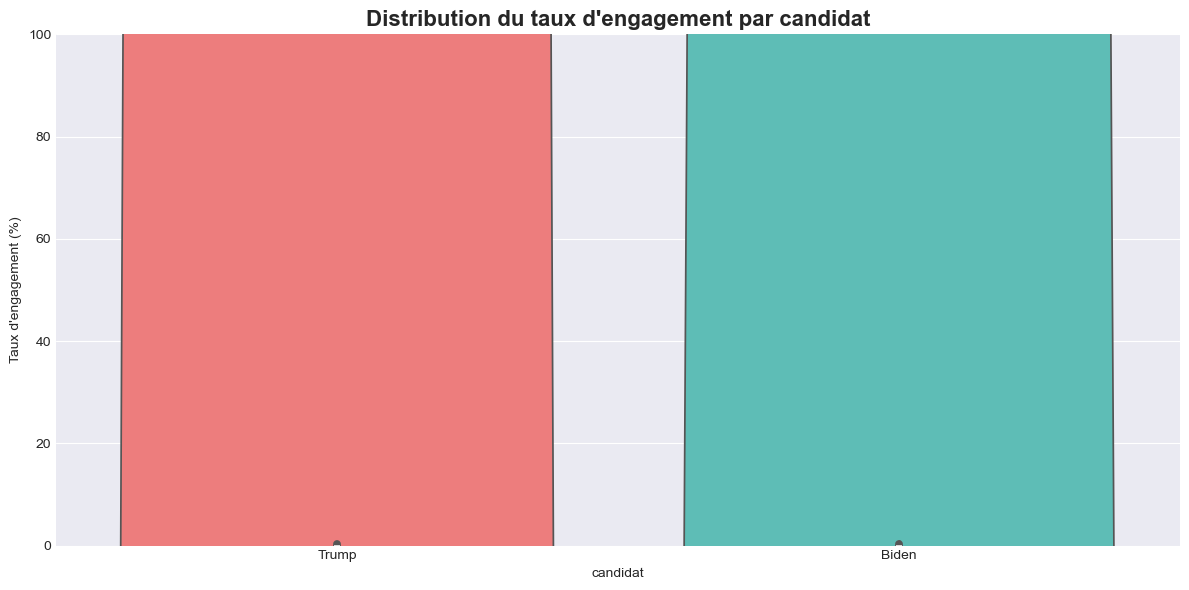

In [17]:
# Calculer les ratios d'engagement
for df in [df_trump, df_biden]:
    df['engagement_rate'] = (df['likes'] + df['retweet_count']) / (df['user_followers_count'] + 1) * 100

print("\nMoyenne du taux d'engagement:")
print(f"Trump: {df_trump['engagement_rate'].mean():.4f}%")
print(f"Biden: {df_biden['engagement_rate'].mean():.4f}%")

# Recréer df_combined avec la colonne engagement_rate
df_combined = pd.concat([df_trump, df_biden], ignore_index=True)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df_combined, x='candidat', y='engagement_rate', palette=['#FF6B6B', '#4ECDC4'])
ax.set_title('Distribution du taux d\'engagement par candidat', fontsize=16, fontweight='bold')
ax.set_ylabel('Taux d\'engagement (%)')
ax.set_ylim(0, df_combined['engagement_rate'].quantile(0.95))  # Limiter à 95% pour mieux voir
plt.tight_layout()
plt.show()


## 10. Résumé des analyses

In [18]:
print("\n" + "="*70)
print("RÉSUMÉ DE L'ANALYSE")
print("="*70)

print(f"\n📊 Période analysée:")
print(f"   Trump: {df_trump['created_at'].min()} → {df_trump['created_at'].max()}")
print(f"   Biden: {df_biden['created_at'].min()} → {df_biden['created_at'].max()}")

print(f"\n📈 Volume de tweets (échantillon):")
print(f"   Trump: {len(df_trump):,} tweets")
print(f"   Biden: {len(df_biden):,} tweets")

print(f"\n❤️ Engagement total:")
print(f"   Trump - Likes: {df_trump['likes'].sum():,.0f} | Retweets: {df_trump['retweet_count'].sum():,.0f}")
print(f"   Biden - Likes: {df_biden['likes'].sum():,.0f} | Retweets: {df_biden['retweet_count'].sum():,.0f}")

print(f"\n📊 Moyennes:")
print(f"   Trump - Likes/tweet: {df_trump['likes'].mean():.2f} | Retweets/tweet: {df_trump['retweet_count'].mean():.2f}")
print(f"   Biden - Likes/tweet: {df_biden['likes'].mean():.2f} | Retweets/tweet: {df_biden['retweet_count'].mean():.2f}")

print(f"\n🌍 Pays principaux:")
print(f"   Trump: {df_trump['country'].mode()[0] if len(df_trump['country'].mode()) > 0 else 'N/A'}")
print(f"   Biden: {df_biden['country'].mode()[0] if len(df_biden['country'].mode()) > 0 else 'N/A'}")

print("\n" + "="*70)


RÉSUMÉ DE L'ANALYSE

📊 Période analysée:
   Trump: 1993-10-01 00:00:00 → 2031-10-29 00:00:00
   Biden: 1978-01-01 00:00:00 → 2073-01-01 00:00:00

📈 Volume de tweets (échantillon):
   Trump: 553,759 tweets
   Biden: 446,328 tweets

❤️ Engagement total:
   Trump - Likes: 3,526,917 | Retweets: 727,474
   Biden - Likes: 4,532,368 | Retweets: 891,187

📊 Moyennes:
   Trump - Likes/tweet: 6.37 | Retweets/tweet: 1.31
   Biden - Likes/tweet: 10.15 | Retweets/tweet: 2.00

🌍 Pays principaux:
   Trump: 
   Biden: 



---

# OBJECTIF 1 - ANALYSE DES SENTIMENTS

## Préparation des données pour l'analyse des sentiments

### Étape 2 : Suppression des colonnes non pertinentes

Suppression des colonnes : `tweet_id`, `collected_at`, `user_description`

In [19]:
# Colonnes à supprimer selon les consignes du TP
columns_to_drop = ['tweet_id', 'collected_at', 'user_description']

print("Colonnes avant suppression:")
print(f"Trump: {df_trump.shape[1]} colonnes")
print(f"Biden: {df_biden.shape[1]} colonnes")

# Supprimer les colonnes si elles existent
for col in columns_to_drop:
    if col in df_trump.columns:
        df_trump = df_trump.drop(columns=[col])
    if col in df_biden.columns:
        df_biden = df_biden.drop(columns=[col])

print("\nColonnes après suppression:")
print(f"Trump: {df_trump.shape[1]} colonnes")
print(f"Biden: {df_biden.shape[1]} colonnes")
print(f"\n✅ Colonnes supprimées: {', '.join(columns_to_drop)}")

Colonnes avant suppression:
Trump: 27 colonnes
Biden: 27 colonnes

Colonnes après suppression:
Trump: 24 colonnes
Biden: 24 colonnes

✅ Colonnes supprimées: tweet_id, collected_at, user_description


### Étape 3 : Filtrage des tweets

Filtrer pour garder uniquement :
- Les tweets publiés aux **États-Unis** (country = 'United States of America')
- Les tweets publiés **avant la fermeture des bureaux de vote** (3 novembre 2020 à 20h)

In [20]:
# Date limite : 3 novembre 2020 à 20h00
cutoff_date = pd.Timestamp('2020-11-03 20:00:00')

print("=" * 70)
print("FILTRAGE DES TWEETS")
print("=" * 70)

# Avant filtrage
print(f"\n📊 AVANT filtrage:")
print(f"   Trump: {len(df_trump):,} tweets")
print(f"   Biden: {len(df_biden):,} tweets")

# Filtrer par pays (États-Unis)
df_trump = df_trump[df_trump['country'] == 'United States of America']
df_biden = df_biden[df_biden['country'] == 'United States of America']

print(f"\n🇺🇸 APRÈS filtrage USA:")
print(f"   Trump: {len(df_trump):,} tweets")
print(f"   Biden: {len(df_biden):,} tweets")

# Filtrer par date (avant 3 nov 2020 20h)
df_trump = df_trump[df_trump['created_at'] < cutoff_date]
df_biden = df_biden[df_biden['created_at'] < cutoff_date]

print(f"\n📅 APRÈS filtrage date (avant 3 nov 2020 20h):")
print(f"   Trump: {len(df_trump):,} tweets")
print(f"   Biden: {len(df_biden):,} tweets")

print("\n" + "=" * 70)
print("✅ Filtrage terminé!")
print("=" * 70)

FILTRAGE DES TWEETS

📊 AVANT filtrage:
   Trump: 553,759 tweets
   Biden: 446,328 tweets

🇺🇸 APRÈS filtrage USA:
   Trump: 103,946 tweets
   Biden: 90,899 tweets

📅 APRÈS filtrage date (avant 3 nov 2020 20h):
   Trump: 71,148 tweets
   Biden: 55,195 tweets

✅ Filtrage terminé!


### Étape 4 : Détection de la langue

Garder uniquement les tweets en **anglais** en utilisant la bibliothèque `langdetect`

In [21]:
# Installation de langdetect si nécessaire
try:
    from langdetect import detect, LangDetectException
except ImportError:
    print("Installation de langdetect...")
    import sys
    !{sys.executable} -m pip install langdetect
    from langdetect import detect, LangDetectException

def detect_language(text):
    """Détecte la langue d'un texte"""
    try:
        if pd.isna(text) or text.strip() == '':
            return None
        return detect(str(text))
    except LangDetectException:
        return None

print("⏳ Détection de la langue des tweets (cela peut prendre quelques minutes)...")

# Détecter la langue pour un échantillon d'abord (pour estimation du temps)
sample_size = 1000
print(f"\n📊 Test sur {sample_size} tweets pour estimation...")

# Trump
df_trump['language'] = None
for idx in df_trump.head(sample_size).index:
    df_trump.at[idx, 'language'] = detect_language(df_trump.at[idx, 'tweet'])

# Appliquer sur tous les tweets Trump
print(f"⏳ Détection langue Trump ({len(df_trump):,} tweets)...")
df_trump['language'] = df_trump['tweet'].apply(detect_language)

# Biden
print(f"⏳ Détection langue Biden ({len(df_biden):,} tweets)...")
df_biden['language'] = df_biden['tweet'].apply(detect_language)

# Statistiques des langues détectées
print("\n📊 Distribution des langues détectées:")
print("\nTrump:")
print(df_trump['language'].value_counts().head(10))
print("\nBiden:")
print(df_biden['language'].value_counts().head(10))

# Filtrer pour garder uniquement l'anglais
print(f"\nFiltrage pour garder uniquement l'anglais...")
df_trump = df_trump[df_trump['language'] == 'en']
df_biden = df_biden[df_biden['language'] == 'en']

print(f"\nAPRÈS filtrage langue:")
print(f"   Trump: {len(df_trump):,} tweets en anglais")
print(f"   Biden: {len(df_biden):,} tweets en anglais")

⏳ Détection de la langue des tweets (cela peut prendre quelques minutes)...

📊 Test sur 1000 tweets pour estimation...
⏳ Détection langue Trump (71,148 tweets)...
⏳ Détection langue Biden (55,195 tweets)...

📊 Distribution des langues détectées:

Trump:
language
en    65046
es     1222
ro     1199
vi      736
de      504
nl      432
id      418
da      244
no      164
fr      153
Name: count, dtype: int64

Biden:
language
en    45308
nl     4740
de     1613
es     1231
da      594
af      262
no      219
id      217
sv      146
fr      144
Name: count, dtype: int64

Filtrage pour garder uniquement l'anglais...

APRÈS filtrage langue:
   Trump: 65,046 tweets en anglais
   Biden: 45,308 tweets en anglais


### Étape 5 : Nettoyage des tweets

Nettoyer les tweets en utilisant des **expressions régulières** pour supprimer :
- Les mentions (@username)
- Les hashtags (#)
- Les liens (URLs)
- Les RT (retweets)
- Convertir en minuscules

In [22]:
import re

def clean_tweet(text):
    """Nettoie un tweet avec regex: supprime RT, mentions, hashtags, URLs, convertit en minuscules"""
    if pd.isna(text):
        return ""
    
    # Convertir en string
    text = str(text)
    
    # Supprimer les RT
    text = re.sub(r'^RT[\s]+', '', text)
    
    # Supprimer les mentions (@username)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    
    # Supprimer les hashtags
    text = re.sub(r'#', '', text)
    
    # Supprimer les URLs (http, https, www)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Convertir en minuscules
    text = text.lower()
    
    # Supprimer les caractères spéciaux et garder seulement lettres, chiffres et espaces
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text)
    
    # Supprimer les espaces au début et à la fin
    text = text.strip()
    
    return text

print("⏳ Nettoyage des tweets...")

# Créer une colonne avec les tweets nettoyés
df_trump['tweet_clean'] = df_trump['tweet'].apply(clean_tweet)
df_biden['tweet_clean'] = df_biden['tweet'].apply(clean_tweet)

# Exemples avant/après
print("\n" + "=" * 70)
print("EXEMPLES DE NETTOYAGE")
print("=" * 70)

print("\n📝 Trump - Avant et Après nettoyage:")
for i in range(3):
    print(f"\nAvant: {df_trump.iloc[i]['tweet'][:100]}...")
    print(f"Après: {df_trump.iloc[i]['tweet_clean'][:100]}...")

print("\n📝 Biden - Avant et Après nettoyage:")
for i in range(3):
    print(f"\nAvant: {df_biden.iloc[i]['tweet'][:100]}...")
    print(f"Après: {df_biden.iloc[i]['tweet_clean'][:100]}...")

print("\n✅ Nettoyage terminé!")

⏳ Nettoyage des tweets...

EXEMPLES DE NETTOYAGE

📝 Trump - Avant et Après nettoyage:

Avant: You get a tie! And you get a tie! #Trump ‘s rally #Iowa https://t.co/jJalUUmh5D...
Après: you get a tie and you get a tie trump s rally iowa...

Avant: @DeeviousDenise @realDonaldTrump @nypost There won’t be many of them.  Unless you all have been voti...
Après: there wont be many of them unless you all have been voting more than once again but god prevails bo ...

Avant: One of the single most effective remedies to eradicate another round of #Trump Plague in our #WhiteH...
Après: one of the single most effective remedies to eradicate another round of trump plague in our whitehou...

📝 Biden - Avant et Après nettoyage:

Avant: Comments on this? "Do Democrats Understand how Ruthless China is?" https://t.co/QevK00yhs3 #China #H...
Après: comments on this do democrats understand how ruthless china is china hunterbiden joebiden bidenharri...

Avant: Twitter is doing everything they can to help Dem

### Étape 6 : Suppression des stop words

Utiliser **NLTK** pour supprimer les mots vides (stop words) en anglais, plus les mots spécifiques : 
`donaldtrump`, `trump`, `donald`, `biden`, `joe`, `joebiden`, `amp`, `president`, `vote`, `voting`, `election`

In [23]:
# Installation et importation de NLTK
try:
    import nltk
    from nltk.corpus import stopwords
except ImportError:
    print("Installation de nltk...")
    import sys
    !{sys.executable} -m pip install nltk
    import nltk
    from nltk.corpus import stopwords

# Télécharger les stop words si nécessaire
print("⏳ Téléchargement des ressources NLTK...")
nltk.download('stopwords', quiet=True)

# Charger les stop words anglais
stop_words = set(stopwords.words('english'))

# Ajouter les mots spécifiques à supprimer selon les consignes
additional_stop_words = {
    'donaldtrump', 'trump', 'donald', 
    'biden', 'joe', 'joebiden', 
    'amp', 'president', 'vote', 'voting', 'election'
}

stop_words = stop_words.union(additional_stop_words)

print(f"📚 Nombre total de stop words: {len(stop_words)}")
print(f"📝 Mots spécifiques ajoutés: {additional_stop_words}")

def remove_stopwords(text):
    """Supprime les stop words d'un texte"""
    if pd.isna(text) or text.strip() == '':
        return ""
    
    # Séparer les mots
    words = text.split()
    
    # Filtrer les stop words
    filtered_words = [word for word in words if word not in stop_words]
    
    # Rejoindre les mots
    return ' '.join(filtered_words)

print("\n⏳ Suppression des stop words...")

# Appliquer la suppression des stop words
df_trump['tweet_processed'] = df_trump['tweet_clean'].apply(remove_stopwords)
df_biden['tweet_processed'] = df_biden['tweet_clean'].apply(remove_stopwords)

# Exemples avant/après suppression des stop words
print("\n" + "=" * 70)
print("EXEMPLES APRÈS SUPPRESSION DES STOP WORDS")
print("=" * 70)

print("\n📝 Trump:")
for i in range(3):
    print(f"\nAvant: {df_trump.iloc[i]['tweet_clean'][:100]}")
    print(f"Après: {df_trump.iloc[i]['tweet_processed'][:100]}")

print("\n📝 Biden:")
for i in range(3):
    print(f"\nAvant: {df_biden.iloc[i]['tweet_clean'][:100]}")
    print(f"Après: {df_biden.iloc[i]['tweet_processed'][:100]}")

# Supprimer les tweets vides après traitement
print(f"\n🔍 Suppression des tweets vides après traitement...")
df_trump = df_trump[df_trump['tweet_processed'].str.strip() != '']
df_biden = df_biden[df_biden['tweet_processed'].str.strip() != '']

print(f"\n✅ Tweets restants après nettoyage complet:")
print(f"   Trump: {len(df_trump):,} tweets")
print(f"   Biden: {len(df_biden):,} tweets")

⏳ Téléchargement des ressources NLTK...
📚 Nombre total de stop words: 209
📝 Mots spécifiques ajoutés: {'donald', 'amp', 'president', 'joebiden', 'trump', 'vote', 'election', 'voting', 'joe', 'donaldtrump', 'biden'}

⏳ Suppression des stop words...

EXEMPLES APRÈS SUPPRESSION DES STOP WORDS

📝 Trump:

Avant: you get a tie and you get a tie trump s rally iowa
Après: get tie get tie rally iowa

Avant: there wont be many of them unless you all have been voting more than once again but god prevails bo 
Après: wont many unless god prevails bo corrupt ever dark light lies coming wouldnt last forever

Avant: one of the single most effective remedies to eradicate another round of trump plague in our whitehou
Après: one single effective remedies eradicate another round plague whitehouse

📝 Biden:

Avant: comments on this do democrats understand how ruthless china is china hunterbiden joebiden bidenharri
Après: comments democrats understand ruthless china china hunterbiden bidenharris bidenharris

### Étape 7 : Analyse des sentiments avec TextBlob

Calcul de la **subjectivité** et de la **polarité** de chaque tweet avec TextBlob.

- **Polarité** : -1 (très négatif) à 1 (très positif)
- **Subjectivité** : 0 (objectif) à 1 (subjectif)

In [24]:
# Installation de TextBlob si nécessaire
try:
    from textblob import TextBlob
except ImportError:
    print("Installation de textblob...")
    import sys
    !{sys.executable} -m pip install textblob
    from textblob import TextBlob
    print("Téléchargement des ressources TextBlob...")
    !python -m textblob.download_corpora

def get_sentiment(text):
    """
    Calcule la polarité et la subjectivité d'un texte
    Retourne: (polarité, subjectivité)
    """
    if pd.isna(text) or text.strip() == '':
        return 0.0, 0.0
    
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.polarity, blob.sentiment.subjectivity
    except:
        return 0.0, 0.0

def get_polarity_state(polarity):
    """
    Détermine l'état de polarité d'un tweet
    - negative : polarité < 0
    - positive : polarité > 0
    - neutral : polarité = 0
    """
    if polarity < 0:
        return 'negative'
    elif polarity > 0:
        return 'positive'
    else:
        return 'neutral'

print("=" * 70)
print("ANALYSE DES SENTIMENTS AVEC TEXTBLOB")
print("=" * 70)

# Analyser les sentiments pour Trump
print(f"\n⏳ Analyse des sentiments Trump ({len(df_trump):,} tweets)...")
print("   Cela peut prendre plusieurs minutes...")

sentiments_trump = df_trump['tweet_processed'].apply(get_sentiment)
df_trump['polarity'] = sentiments_trump.apply(lambda x: x[0])
df_trump['subjectivity'] = sentiments_trump.apply(lambda x: x[1])
df_trump['pol_state'] = df_trump['polarity'].apply(get_polarity_state)

# Analyser les sentiments pour Biden
print(f"⏳ Analyse des sentiments Biden ({len(df_biden):,} tweets)...")
sentiments_biden = df_biden['tweet_processed'].apply(get_sentiment)
df_biden['polarity'] = sentiments_biden.apply(lambda x: x[0])
df_biden['subjectivity'] = sentiments_biden.apply(lambda x: x[1])
df_biden['pol_state'] = df_biden['polarity'].apply(get_polarity_state)

print("\n✅ Analyse des sentiments terminée!")

# Afficher les statistiques
print("\n" + "=" * 70)
print("STATISTIQUES DES SENTIMENTS")
print("=" * 70)

print("\n📊 Trump:")
print(f"   Polarité moyenne: {df_trump['polarity'].mean():.4f}")
print(f"   Subjectivité moyenne: {df_trump['subjectivity'].mean():.4f}")
print(f"\n   Distribution:")
print(df_trump['pol_state'].value_counts())
print(f"\n   Pourcentages:")
print(df_trump['pol_state'].value_counts(normalize=True) * 100)

print("\n📊 Biden:")
print(f"   Polarité moyenne: {df_biden['polarity'].mean():.4f}")
print(f"   Subjectivité moyenne: {df_biden['subjectivity'].mean():.4f}")
print(f"\n   Distribution:")
print(df_biden['pol_state'].value_counts())
print(f"\n   Pourcentages:")
print(df_biden['pol_state'].value_counts(normalize=True) * 100)

# Exemples de tweets avec leurs sentiments
print("\n" + "=" * 70)
print("EXEMPLES DE TWEETS AVEC LEURS SENTIMENTS")
print("=" * 70)

print("\n📝 Trump - Tweets les plus positifs:")
top_positive_trump = df_trump.nlargest(3, 'polarity')[['tweet', 'polarity', 'subjectivity', 'pol_state']]
for idx, row in top_positive_trump.iterrows():
    print(f"\nTweet: {row['tweet'][:150]}...")
    print(f"Polarité: {row['polarity']:.3f} | Subjectivité: {row['subjectivity']:.3f} | État: {row['pol_state']}")

print("\n📝 Trump - Tweets les plus négatifs:")
top_negative_trump = df_trump.nsmallest(3, 'polarity')[['tweet', 'polarity', 'subjectivity', 'pol_state']]
for idx, row in top_negative_trump.iterrows():
    print(f"\nTweet: {row['tweet'][:150]}...")
    print(f"Polarité: {row['polarity']:.3f} | Subjectivité: {row['subjectivity']:.3f} | État: {row['pol_state']}")

ANALYSE DES SENTIMENTS AVEC TEXTBLOB

⏳ Analyse des sentiments Trump (64,894 tweets)...
   Cela peut prendre plusieurs minutes...
⏳ Analyse des sentiments Biden (45,196 tweets)...

✅ Analyse des sentiments terminée!

STATISTIQUES DES SENTIMENTS

📊 Trump:
   Polarité moyenne: 0.0267
   Subjectivité moyenne: 0.3316

   Distribution:
pol_state
neutral     26997
positive    21762
negative    16135
Name: count, dtype: int64

   Pourcentages:
pol_state
neutral     41.601689
positive    33.534687
negative    24.863624
Name: proportion, dtype: float64

📊 Biden:
   Polarité moyenne: 0.0631
   Subjectivité moyenne: 0.3288

   Distribution:
pol_state
neutral     18461
positive    17315
negative     9420
Name: count, dtype: int64

   Pourcentages:
pol_state
neutral     40.846535
positive    38.310912
negative    20.842552
Name: proportion, dtype: float64

EXEMPLES DE TWEETS AVEC LEURS SENTIMENTS

📝 Trump - Tweets les plus positifs:

Tweet: Via @RawStory: It’s been one faceplant after another as Tr

### Étape 8 : Fonction de génération de nuages de mots (Word Cloud)

Création de la fonction `getWordCloud` pour visualiser les mots les plus fréquents

NUAGES DE MOTS

🎨 Génération du nuage de mots pour Trump...


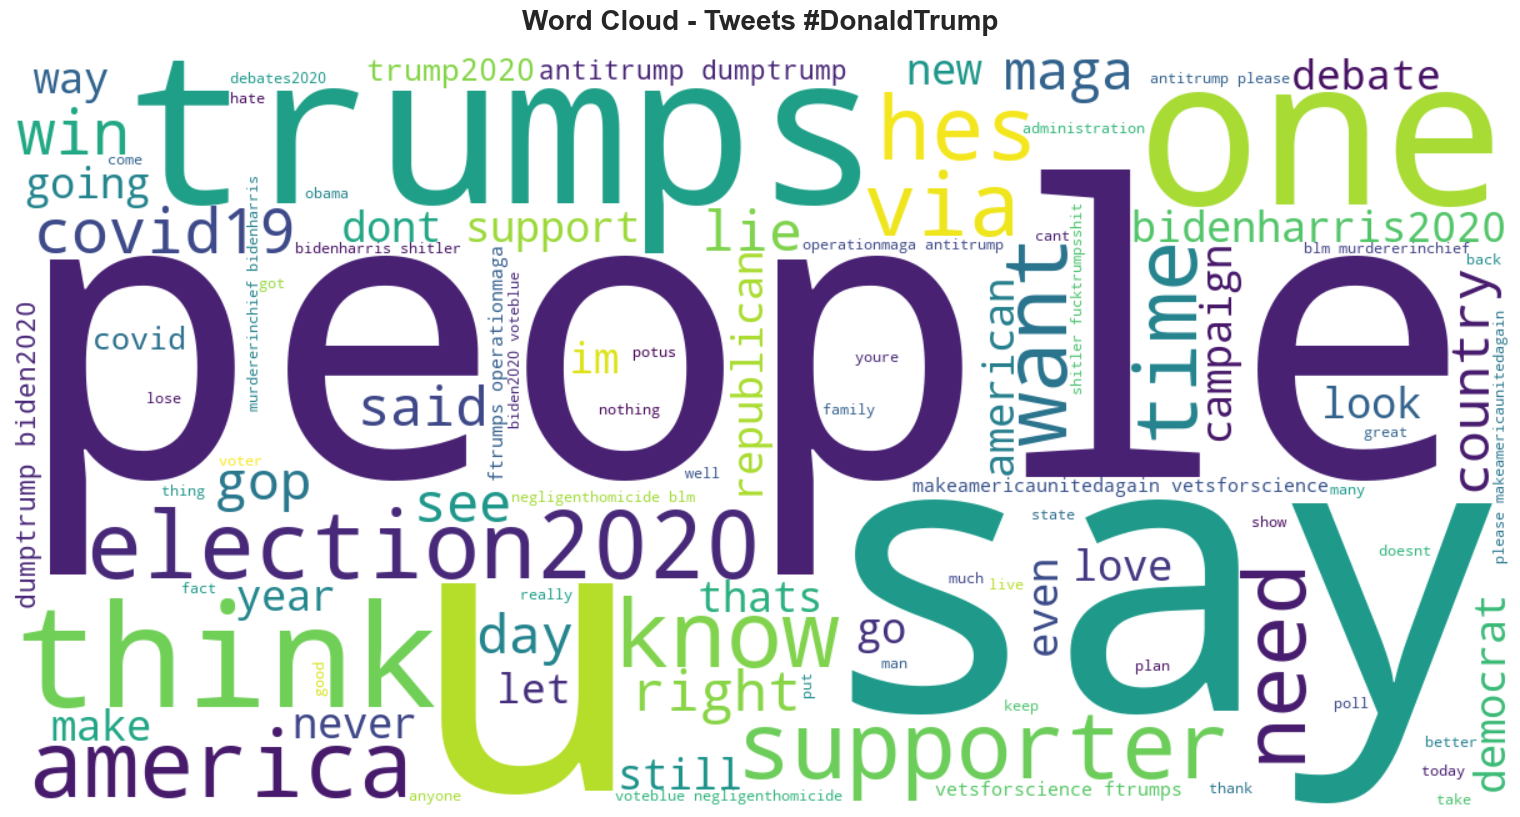


📊 Top 20 des mots les plus fréquents dans Word Cloud - Tweets #DonaldTrump:
    1. people               (fréquence relative: 1.0000)
    2. say                  (fréquence relative: 0.9120)
    3. u                    (fréquence relative: 0.9117)
    4. trumps               (fréquence relative: 0.8222)
    5. one                  (fréquence relative: 0.7831)
    6. think                (fréquence relative: 0.6678)
    7. election2020         (fréquence relative: 0.6530)
    8. know                 (fréquence relative: 0.6515)
    9. america              (fréquence relative: 0.6264)
   10. supporter            (fréquence relative: 0.6190)
   11. hes                  (fréquence relative: 0.5732)
   12. want                 (fréquence relative: 0.5569)
   13. via                  (fréquence relative: 0.5495)
   14. need                 (fréquence relative: 0.5299)
   15. time                 (fréquence relative: 0.5273)
   16. covid19              (fréquence relative: 0.5207)
   17. win 

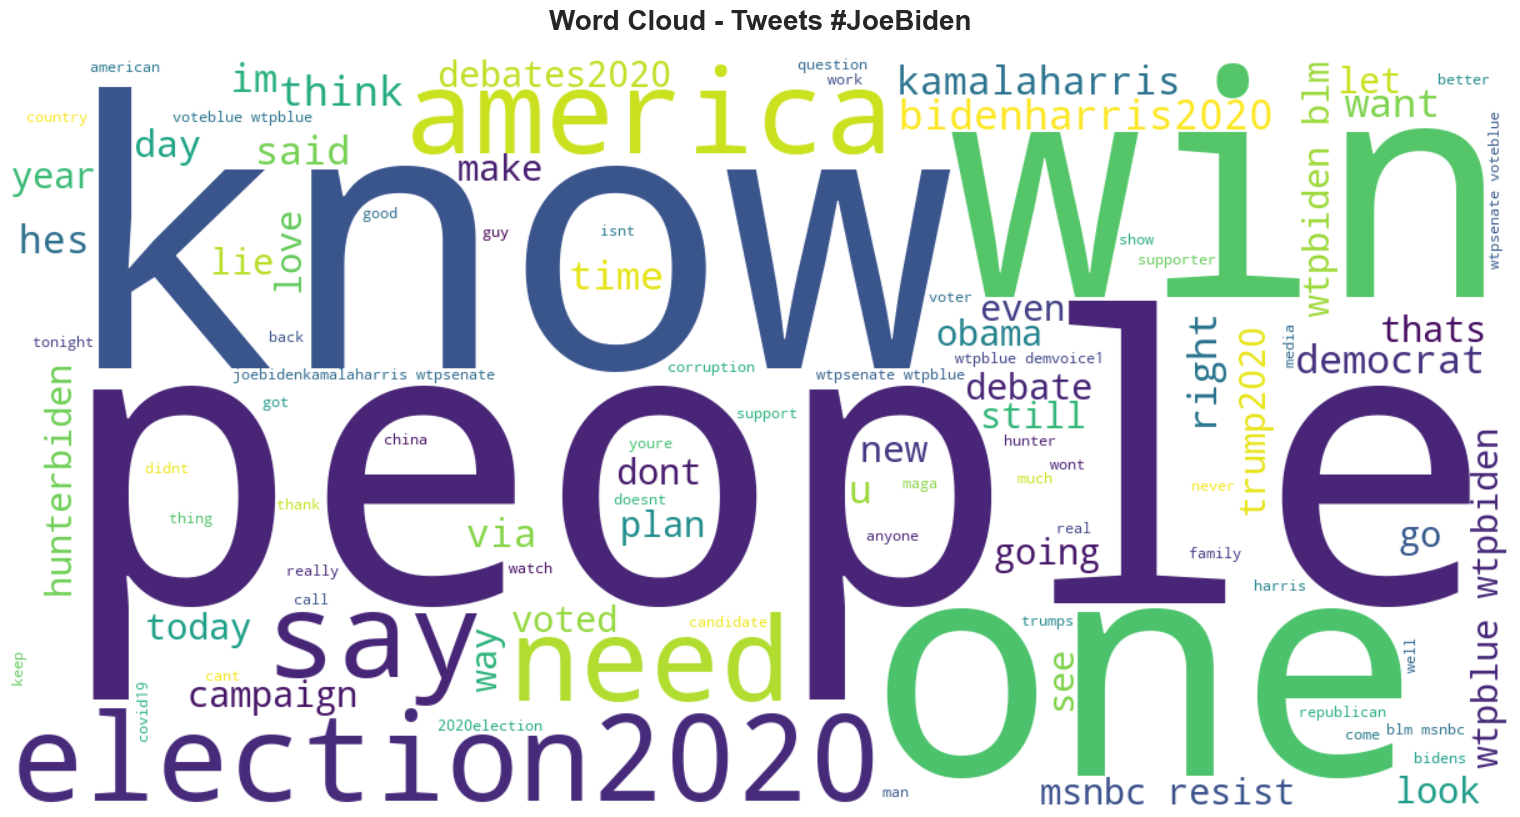


📊 Top 20 des mots les plus fréquents dans Word Cloud - Tweets #JoeBiden:
    1. people               (fréquence relative: 1.0000)
    2. know                 (fréquence relative: 0.8571)
    3. win                  (fréquence relative: 0.8506)
    4. one                  (fréquence relative: 0.8414)
    5. election2020         (fréquence relative: 0.8381)
    6. say                  (fréquence relative: 0.8235)
    7. america              (fréquence relative: 0.7639)
    8. need                 (fréquence relative: 0.7596)
    9. bidenharris2020      (fréquence relative: 0.7071)
   10. think                (fréquence relative: 0.6892)
   11. want                 (fréquence relative: 0.6308)
   12. democrat             (fréquence relative: 0.6232)
   13. right                (fréquence relative: 0.6080)
   14. im                   (fréquence relative: 0.6048)
   15. time                 (fréquence relative: 0.5994)
   16. said                 (fréquence relative: 0.5836)
   17. u      

In [25]:
# Installation de wordcloud si nécessaire
try:
    from wordcloud import WordCloud
except ImportError:
    print("Installation de wordcloud...")
    import sys
    !{sys.executable} -m pip install wordcloud
    from wordcloud import WordCloud

def getWordCloud(df, title="Word Cloud"):
    """
    Génère et affiche un nuage de mots à partir des tweets d'un dataframe
    
    Paramètres:
    - df: DataFrame contenant une colonne 'tweet_processed'
    - title: Titre du graphique
    """
    # Combiner tous les tweets en un seul texte
    all_words = ' '.join(df['tweet_processed'].astype(str))
    
    # Créer le nuage de mots
    wordcloud = WordCloud(
        width=1200, 
        height=600,
        background_color='white',
        colormap='viridis',
        max_words=100,
        relative_scaling=0.5,
        min_font_size=10
    ).generate(all_words)
    
    # Afficher le nuage de mots
    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20, fontweight='bold', pad=20)
    plt.tight_layout(pad=0)
    plt.show()
    
    # Afficher les 20 mots les plus fréquents
    word_freq = wordcloud.words_
    top_20 = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:20]
    
    print(f"\n📊 Top 20 des mots les plus fréquents dans {title}:")
    for i, (word, freq) in enumerate(top_20, 1):
        print(f"   {i:2d}. {word:20s} (fréquence relative: {freq:.4f})")

# Générer les nuages de mots
print("=" * 70)
print("NUAGES DE MOTS")
print("=" * 70)

print("\n🎨 Génération du nuage de mots pour Trump...")
getWordCloud(df_trump, title="Word Cloud - Tweets #DonaldTrump")

print("\n🎨 Génération du nuage de mots pour Biden...")
getWordCloud(df_biden, title="Word Cloud - Tweets #JoeBiden")

### Étape 9 : Fonction de visualisation de la polarité

Création de la fonction `getInfoPolarity` pour afficher :
- Les pourcentages de tweets positifs, négatifs et neutres
- Un diagramme circulaire (pie chart) des sentiments

ANALYSE DE POLARITÉ - Donald Trump

📊 Distribution des sentiments:
   Total de tweets analysés: 64,894
   Positive  :   21,762 tweets (33.53%)
   Negative  :   16,135 tweets (24.86%)
   Neutral   :   26,997 tweets (41.60%)


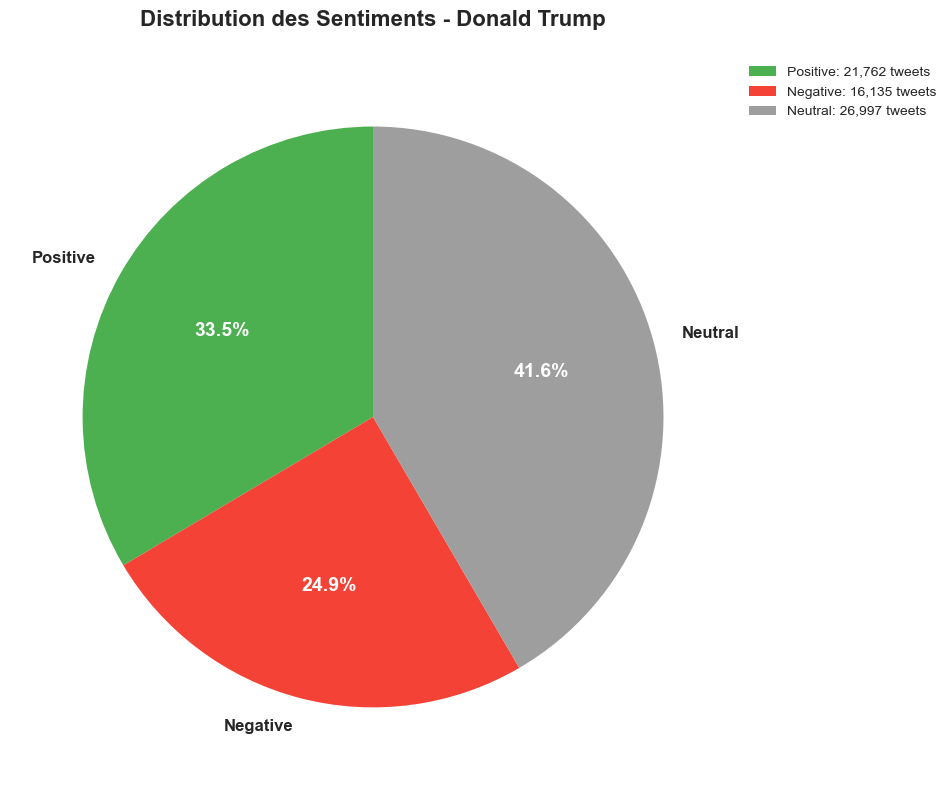


ANALYSE DE POLARITÉ - Joe Biden

📊 Distribution des sentiments:
   Total de tweets analysés: 45,196
   Positive  :   17,315 tweets (38.31%)
   Negative  :    9,420 tweets (20.84%)
   Neutral   :   18,461 tweets (40.85%)


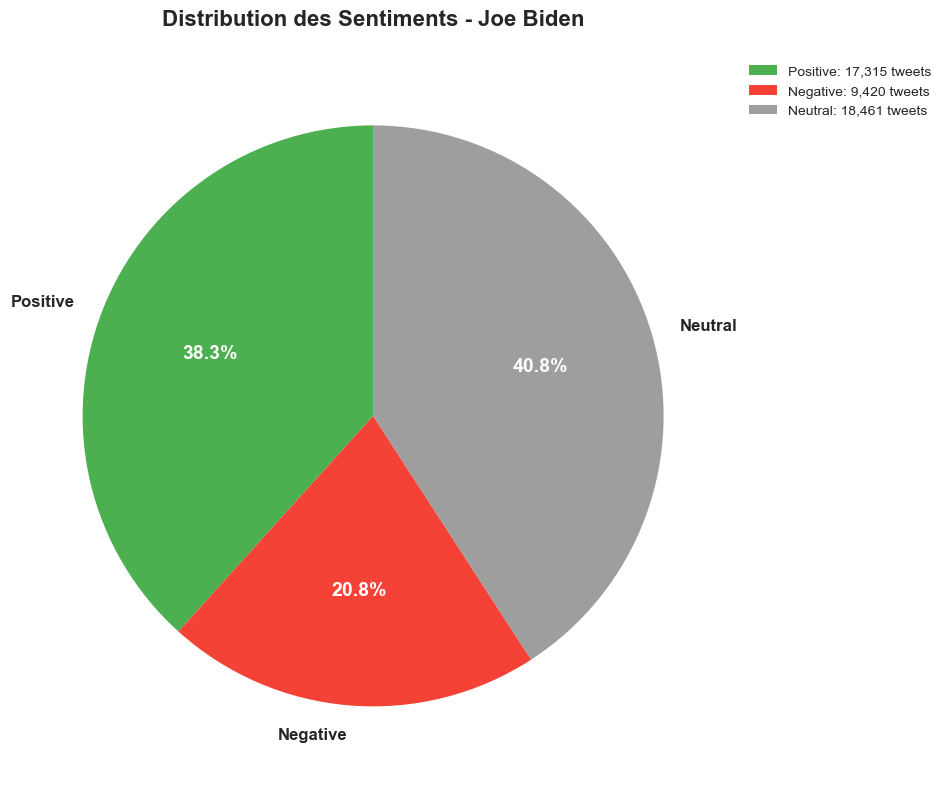

In [26]:
def getInfoPolarity(df, candidate_name):
    """
    Calcule et affiche les statistiques de polarité des tweets:
    - Pourcentages de tweets positifs, négatifs et neutres
    - Diagramme circulaire (pie chart) de la distribution
    
    Paramètres:
    - df: DataFrame contenant une colonne 'pol_state'
    - candidate_name: Nom du candidat pour le titre
    """
    # Calculer les pourcentages
    pol_counts = df['pol_state'].value_counts()
    pol_percentages = df['pol_state'].value_counts(normalize=True) * 100
    
    # Afficher les pourcentages
    print("=" * 70)
    print(f"ANALYSE DE POLARITÉ - {candidate_name}")
    print("=" * 70)
    
    print(f"\n📊 Distribution des sentiments:")
    print(f"   Total de tweets analysés: {len(df):,}")
    
    for sentiment in ['positive', 'negative', 'neutral']:
        if sentiment in pol_percentages:
            count = pol_counts[sentiment]
            pct = pol_percentages[sentiment]
            print(f"   {sentiment.capitalize():10s}: {count:8,} tweets ({pct:5.2f}%)")
    
    # Créer le pie chart
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Couleurs pour chaque catégorie
    colors = {
        'positive': '#4CAF50',  # Vert
        'negative': '#F44336',  # Rouge
        'neutral': '#9E9E9E'    # Gris
    }
    
    # Préparer les données pour le pie chart
    labels = []
    sizes = []
    chart_colors = []
    
    for sentiment in ['positive', 'negative', 'neutral']:
        if sentiment in pol_counts:
            labels.append(sentiment.capitalize())
            sizes.append(pol_counts[sentiment])
            chart_colors.append(colors[sentiment])
    
    # Créer le pie chart
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=chart_colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12, 'weight': 'bold'}
    )
    
    # Améliorer la lisibilité
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(14)
        autotext.set_weight('bold')
    
    ax.set_title(f'Distribution des Sentiments - {candidate_name}', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Ajouter une légende avec les nombres
    legend_labels = [f'{label}: {size:,} tweets' 
                    for label, size in zip(labels, sizes)]
    ax.legend(legend_labels, loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 70)

# Appliquer la fonction sur les deux candidats
getInfoPolarity(df_trump, "Donald Trump")
getInfoPolarity(df_biden, "Joe Biden")

### Comparaison des sentiments entre Trump et Biden

Visualisation comparative de la polarité des tweets pour les deux candidats

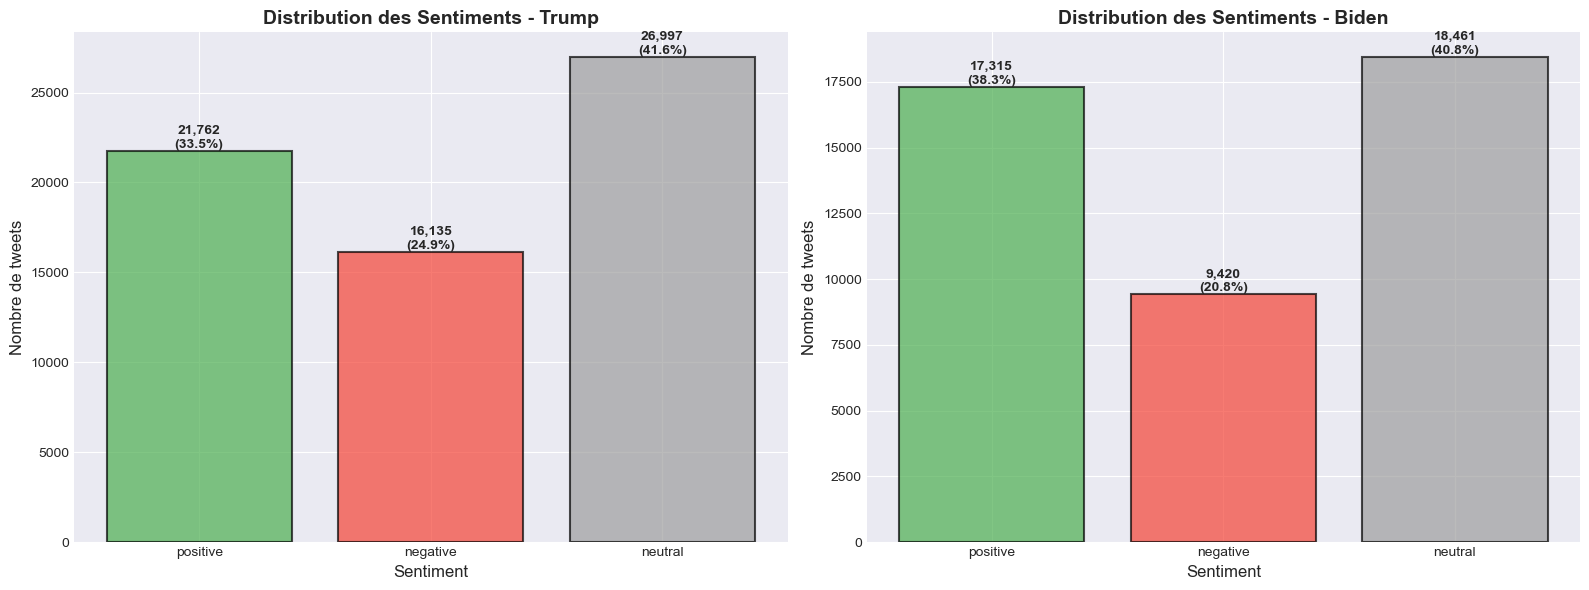


TABLEAU COMPARATIF DES SENTIMENTS


,Candidat,Tweets Positifs,Tweets Négatifs,Tweets Neutres,Polarité Moyenne,Subjectivité Moyenne
0,Trump,"21,762 (33.5%)","16,135 (24.9%)","26,997 (41.6%)",0.0267,0.3316
1,Biden,"17,315 (38.3%)","9,420 (20.8%)","18,461 (40.8%)",0.0631,0.3288



✅ OBJECTIF 1 TERMINÉ - Analyse des sentiments complète!


In [27]:
# Comparaison graphique des sentiments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Données pour la comparaison
candidates = ['Trump', 'Biden']
dfs = [df_trump, df_biden]
colors_cand = ['#FF6B6B', '#4ECDC4']

for idx, (candidate, df, color) in enumerate(zip(candidates, dfs, colors_cand)):
    pol_counts = df['pol_state'].value_counts()
    
    # Graphique en barres
    sentiments = ['positive', 'negative', 'neutral']
    counts = [pol_counts.get(s, 0) for s in sentiments]
    bar_colors = ['#4CAF50', '#F44336', '#9E9E9E']
    
    axes[idx].bar(sentiments, counts, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'Distribution des Sentiments - {candidate}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Nombre de tweets', fontsize=12)
    axes[idx].set_xlabel('Sentiment', fontsize=12)
    axes[idx].ticklabel_format(style='plain', axis='y')
    
    # Ajouter les valeurs sur les barres
    for i, (sentiment, count) in enumerate(zip(sentiments, counts)):
        pct = (count / len(df)) * 100
        axes[idx].text(i, count, f'{count:,}\n({pct:.1f}%)', 
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Tableau comparatif
print("\n" + "=" * 70)
print("TABLEAU COMPARATIF DES SENTIMENTS")
print("=" * 70)

comparison_data = []
for candidate, df in zip(['Trump', 'Biden'], [df_trump, df_biden]):
    pol_counts = df['pol_state'].value_counts()
    pol_pct = df['pol_state'].value_counts(normalize=True) * 100
    
    row = {
        'Candidat': candidate,
        'Tweets Positifs': f"{pol_counts.get('positive', 0):,} ({pol_pct.get('positive', 0):.1f}%)",
        'Tweets Négatifs': f"{pol_counts.get('negative', 0):,} ({pol_pct.get('negative', 0):.1f}%)",
        'Tweets Neutres': f"{pol_counts.get('neutral', 0):,} ({pol_pct.get('neutral', 0):.1f}%)",
        'Polarité Moyenne': f"{df['polarity'].mean():.4f}",
        'Subjectivité Moyenne': f"{df['subjectivity'].mean():.4f}"
    }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

print("\n✅ OBJECTIF 1 TERMINÉ - Analyse des sentiments complète!")

---

# OBJECTIF 2 - ANALYSE DES RELATIONS ENTRE SENTIMENTS ET VOTE

## Analyse de corrélation entre les sentiments Twitter et les résultats de vote réels


### Étape 10 : Calcul de la polarité moyenne par État

Calculer la polarité moyenne de tous les Tweets dans chaque État pour chaque candidat.


In [28]:
print("=" * 70)
print("CALCUL DE LA POLARITÉ MOYENNE PAR ÉTAT")
print("=" * 70)

# Calculer la polarité moyenne par état pour Trump
trump_polarity_by_state = df_trump.groupby('state_code')['polarity'].mean().reset_index()
trump_polarity_by_state.columns = ['state_code', 'mean_polarity']
trump_polarity_by_state['candidat'] = 'Trump'

print(f"\n📊 Polarité moyenne par État - Trump:")
print(f"   Nombre d'États: {len(trump_polarity_by_state)}")
print(f"   Polarité moyenne globale: {trump_polarity_by_state['mean_polarity'].mean():.4f}")
print(f"\n   Top 5 États les plus positifs:")
print(trump_polarity_by_state.nlargest(5, 'mean_polarity')[['state_code', 'mean_polarity']])
print(f"\n   Top 5 États les plus négatifs:")
print(trump_polarity_by_state.nsmallest(5, 'mean_polarity')[['state_code', 'mean_polarity']])

# Calculer la polarité moyenne par état pour Biden
biden_polarity_by_state = df_biden.groupby('state_code')['polarity'].mean().reset_index()
biden_polarity_by_state.columns = ['state_code', 'mean_polarity']
biden_polarity_by_state['candidat'] = 'Biden'

print(f"\n📊 Polarité moyenne par État - Biden:")
print(f"   Nombre d'États: {len(biden_polarity_by_state)}")
print(f"   Polarité moyenne globale: {biden_polarity_by_state['mean_polarity'].mean():.4f}")
print(f"\n   Top 5 États les plus positifs:")
print(biden_polarity_by_state.nlargest(5, 'mean_polarity')[['state_code', 'mean_polarity']])
print(f"\n   Top 5 États les plus négatifs:")
print(biden_polarity_by_state.nsmallest(5, 'mean_polarity')[['state_code', 'mean_polarity']])

print("\n" + "=" * 70)
print("✅ Calcul de la polarité moyenne par État terminé!")
print("=" * 70)


CALCUL DE LA POLARITÉ MOYENNE PAR ÉTAT

📊 Polarité moyenne par État - Trump:
   Nombre d'États: 54
   Polarité moyenne globale: 0.0174

   Top 5 États les plus positifs:
   state_code  mean_polarity
0                   0.375000
53         WY       0.098662
52         WV       0.091442
2          AL       0.085656
31         NE       0.070788

   Top 5 États les plus négatifs:
   state_code  mean_polarity
12         GU      -1.000000
39         OR      -0.035141
9          DE      -0.018506
30         ND      -0.016292
15         ID      -0.006157

📊 Polarité moyenne par État - Biden:
   Nombre d'États: 55
   Polarité moyenne globale: 0.0589

   Top 5 États les plus positifs:
   state_code  mean_polarity
27         MP       0.250000
38         OH       0.124188
0                   0.101871
53         WV       0.091939
13         HI       0.086236

   Top 5 États les plus négatifs:
   state_code  mean_polarity
28         MS      -0.014518
29         MT      -0.004947
12         GU       

### Étape 11 : Fusion des données de vote avec les données Twitter

Créer une fonction qui fusionne les données de vote avec les données des Tweets en utilisant les codes des États.


In [29]:
# Charger les données de vote
print("Chargement des données de vote...")

if not os.path.exists('data/ap_votes.csv'):
    print("\nERREUR: Le fichier 'data/ap_votes.csv' est introuvable.")
    print(f"Chemin actuel: {os.getcwd()}")
    print("\nAssurez-vous que le fichier ap_votes.csv est dans le dossier 'data/'.")
    print("Ce fichier contient les résultats électoraux officiels de 2020.")
else:
    df_votes = pd.read_csv('data/ap_votes.csv')

    print("\n" + "=" * 70)
    print("DONNÉES DE VOTE - ÉLECTION PRÉSIDENTIELLE 2020")
    print("=" * 70)
    print(f"\nNombre d'États: {len(df_votes)}")
    print(f"\n   Colonnes disponibles: {list(df_votes.columns)}")
    print(f"\n   Aperçu des données:")
    display(df_votes.head(10))

    print(f"\nStatistiques globales:")
    print(f"   États remportés par Trump: {df_votes['trump_win'].sum()}")
    print(f"   États remportés par Biden: {df_votes['biden_win'].sum()}")
    print(f"   Pourcentage moyen Trump: {df_votes['trump_pct'].mean():.2f}%")
    print(f"   Pourcentage moyen Biden: {df_votes['biden_pct'].mean():.2f}%")

    def merge_vote_twitter_data(polarity_by_state, vote_data, candidate_name):
        """
        Fusionne les données de polarité Twitter avec les données de vote
        
        Paramètres:
        - polarity_by_state: DataFrame contenant state_code et mean_polarity
        - vote_data: DataFrame contenant les résultats de vote (ap_votes.csv)
        - candidate_name: 'Trump' ou 'Biden'
        
        Retourne:
        - DataFrame fusionné avec polarité et résultats de vote
        """
        merged = pd.merge(
            polarity_by_state,
            vote_data,
            left_on='state_code',
            right_on='state_abr',
            how='inner'
        )
        
        print(f"\nFusion réussie pour {candidate_name}:")
        print(f"   États avec données Twitter: {len(polarity_by_state)}")
        print(f"   États avec données de vote: {len(vote_data)}")
        print(f"   États dans le résultat fusionné: {len(merged)}")
        
        return merged

    print("\n" + "=" * 70)
    print("FUSION DES DONNÉES")
    print("=" * 70)

    # Fusionner pour Trump
    trump_merged = merge_vote_twitter_data(trump_polarity_by_state, df_votes, 'Trump')

    # Fusionner pour Biden
    biden_merged = merge_vote_twitter_data(biden_polarity_by_state, df_votes, 'Biden')

    print("\nAperçu Trump fusionné:")
    display(trump_merged[['state', 'state_code', 'mean_polarity', 'trump_pct', 'trump_win']].head(10))

    print("\nAperçu Biden fusionné:")
    display(biden_merged[['state', 'state_code', 'mean_polarity', 'biden_pct', 'biden_win']].head(10))

    print("\n" + "=" * 70)
    print("Fusion des données terminée!")
    print("=" * 70)

Chargement des données de vote...

DONNÉES DE VOTE - ÉLECTION PRÉSIDENTIELLE 2020

Nombre d'États: 51

   Colonnes disponibles: ['state', 'state_abr', 'trump_pct', 'biden_pct', 'trump_vote', 'biden_vote', 'trump_win', 'biden_win']

   Aperçu des données:


,state,state_abr,trump_pct,biden_pct,trump_vote,biden_vote,trump_win,biden_win
0,Alaska,AK,53.1,43.0,189543,153502,1,0
1,Hawaii,HI,34.3,63.7,196864,366130,0,1
2,Washington,WA,39.0,58.4,1584651,2369612,0,1
3,Oregon,OR,40.7,56.9,958448,1340383,0,1
4,California,CA,34.3,63.5,5982194,11082293,0,1
5,Idaho,ID,63.9,33.1,554128,287031,1,0
6,Montana,MT,56.9,40.6,343647,244836,1,0
7,Nevada,NV,47.7,50.1,669890,703486,0,1
8,Wyoming,WY,70.4,26.7,193559,73491,1,0
9,Utah,UT,58.2,37.7,865140,560282,1,0



Statistiques globales:
   États remportés par Trump: 25
   États remportés par Biden: 26
   Pourcentage moyen Trump: 49.37%
   Pourcentage moyen Biden: 48.66%

FUSION DES DONNÉES

Fusion réussie pour Trump:
   États avec données Twitter: 54
   États avec données de vote: 51
   États dans le résultat fusionné: 51

Fusion réussie pour Biden:
   États avec données Twitter: 55
   États avec données de vote: 51
   États dans le résultat fusionné: 51

Aperçu Trump fusionné:


,state,state_code,mean_polarity,trump_pct,trump_win
0,Alaska,AK,0.061657,53.1,1
1,Alabama,AL,0.085656,62.2,1
2,Arkansas,AR,0.027996,62.4,1
3,Arizona,AZ,0.048965,49.1,0
4,California,CA,0.020632,34.3,0
5,Colorado,CO,0.007061,41.9,0
6,Connecticut,CT,0.003066,39.2,0
7,District of Columbia,DC,0.025782,5.4,0
8,Delaware,DE,-0.018506,39.8,0
9,Florida,FL,0.046893,51.2,1



Aperçu Biden fusionné:


,state,state_code,mean_polarity,biden_pct,biden_win
0,Alaska,AK,0.036896,43.0,0
1,Alabama,AL,0.061255,36.7,0
2,Arkansas,AR,0.052307,34.8,0
3,Arizona,AZ,0.053256,49.4,1
4,California,CA,0.066416,63.5,1
5,Colorado,CO,0.055066,55.4,1
6,Connecticut,CT,0.061878,59.3,1
7,District of Columbia,DC,0.064573,93.0,1
8,Delaware,DE,0.056019,58.8,1
9,Florida,FL,0.056268,47.9,0



Fusion des données terminée!


### Étape 12 : Régression linéaire par les moindres carrés

Créer une fonction de régression linéaire basée sur les moindres carrés (développée from scratch).

**Méthode des moindres carrés** : 
- Objectif : trouver la droite $y = mx + b$ qui minimise la somme des carrés des erreurs
- Formules : 
  - $m = \frac{n\sum(xy) - \sum x \sum y}{n\sum(x^2) - (\sum x)^2}$
  - $b = \frac{\sum y - m\sum x}{n}$


In [30]:
def linear_regression(x, y):
    """
    Calcule la régression linéaire par les moindres carrés.
    
    Formule de la droite : y = mx + b
    - m : pente (slope)
    - b : ordonnée à l'origine (intercept)
    - R² : coefficient de détermination
    
    Paramètres:
    - x: variable indépendante (array)
    - y: variable dépendante (array)
    
    Retour:
    - m (pente), b (ordonnée), r2 (coefficient R²)
    """
    n = len(x)
    
    # Calcul des sommes nécessaires
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)
    
    # Calcul de la pente (m) et de l'ordonnée (b)
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    b = (sum_y - m * sum_x) / n
    
    # Calcul du coefficient de détermination R²
    y_pred = m * x + b
    ss_res = np.sum((y - y_pred) ** 2)  # Somme des carrés des résidus
    ss_tot = np.sum((y - np.mean(y)) ** 2)  # Somme totale des carrés
    r2 = 1 - (ss_res / ss_tot)
    
    return m, b, r2

# Test de la fonction avec des données simples
print("Test de la fonction linear_regression:")
x_test = np.array([1, 2, 3, 4, 5])
y_test = np.array([2, 4, 5, 4, 5])
m_test, b_test, r2_test = linear_regression(x_test, y_test)

print(f"   Données de test:")
print(f"   x = {x_test}")
print(f"   y = {y_test}")
print(f"\n   Résultats:")
print(f"   Pente (m) = {m_test:.4f}")
print(f"   Ordonnée (b) = {b_test:.4f}")
print(f"   R² = {r2_test:.4f}")
print(f"   Équation: y = {m_test:.4f}x + {b_test:.4f}")

Test de la fonction linear_regression:
   Données de test:
   x = [1 2 3 4 5]
   y = [2 4 5 4 5]

   Résultats:
   Pente (m) = 0.6000
   Ordonnée (b) = 2.2000
   R² = 0.6000
   Équation: y = 0.6000x + 2.2000


### Étape 13 : Application de la régression

Appliquer la régression linéaire entre le pourcentage de votes et la polarité des tweets pour chaque candidat.


In [31]:
# Application de la régression linéaire pour chaque candidat

# TRUMP: Polarité moyenne vs Pourcentage de votes
print("\n📊 RÉGRESSION LINÉAIRE - TRUMP")
print("Variable X: Polarité moyenne des tweets")
print("Variable Y: Pourcentage de votes pour Trump")

m_trump, b_trump, r2_trump = linear_regression(
    trump_merged['mean_polarity'].values,
    trump_merged['trump_pct'].values
)

print(f"\n✅ Résultats de la régression (Trump):")
print(f"   - Pente (m): {m_trump:.6f}")
print(f"   - Ordonnée à l'origine (b): {b_trump:.4f}")
print(f"   - Coefficient R² : {r2_trump:.4f}")

if r2_trump < 0.3:
    print("   ➡️ Interprétation: Faible corrélation - La polarité Twitter prédit mal les votes")
elif r2_trump < 0.7:
    print("   ➡️ Interprétation: Corrélation modérée - Pouvoir prédictif limité")
else:
    print("   ➡️ Interprétation: Forte corrélation - La polarité Twitter reflète bien les votes")

# BIDEN: Polarité moyenne vs Pourcentage de votes
print("\n📊 RÉGRESSION LINÉAIRE - BIDEN")
print("Variable X: Polarité moyenne des tweets")
print("Variable Y: Pourcentage de votes pour Biden")

m_biden, b_biden, r2_biden = linear_regression(
    biden_merged['mean_polarity'].values,
    biden_merged['biden_pct'].values
)

print(f"\n✅ Résultats de la régression (Biden):")
print(f"   - Pente (m): {m_biden:.6f}")
print(f"   - Ordonnée à l'origine (b): {b_biden:.4f}")
print(f"   - Coefficient R² : {r2_biden:.4f}")

if r2_biden < 0.3:
    print("   ➡️ Interprétation: Faible corrélation - La polarité Twitter prédit mal les votes")
elif r2_biden < 0.7:
    print("   ➡️ Interprétation: Corrélation modérée - Pouvoir prédictif limité")
else:
    print("   ➡️ Interprétation: Forte corrélation - La polarité Twitter reflète bien les votes")


📊 RÉGRESSION LINÉAIRE - TRUMP
Variable X: Polarité moyenne des tweets
Variable Y: Pourcentage de votes pour Trump

✅ Résultats de la régression (Trump):
   - Pente (m): 160.468020
   - Ordonnée à l'origine (b): 44.5107
   - Coefficient R² : 0.1368
   ➡️ Interprétation: Faible corrélation - La polarité Twitter prédit mal les votes

📊 RÉGRESSION LINÉAIRE - BIDEN
Variable X: Polarité moyenne des tweets
Variable Y: Pourcentage de votes pour Biden

✅ Résultats de la régression (Biden):
   - Pente (m): 86.916547
   - Ordonnée à l'origine (b): 43.8555
   - Coefficient R² : 0.0260
   ➡️ Interprétation: Faible corrélation - La polarité Twitter prédit mal les votes


### Étape 14 : Fonction scatterplot

Créer une fonction qui projette les données en nuage de points (scatterplot) avec la droite de régression.


VISUALISATION: POLARITÉ vs POURCENTAGE DE VOTES

📊 Génération du scatterplot pour Trump...


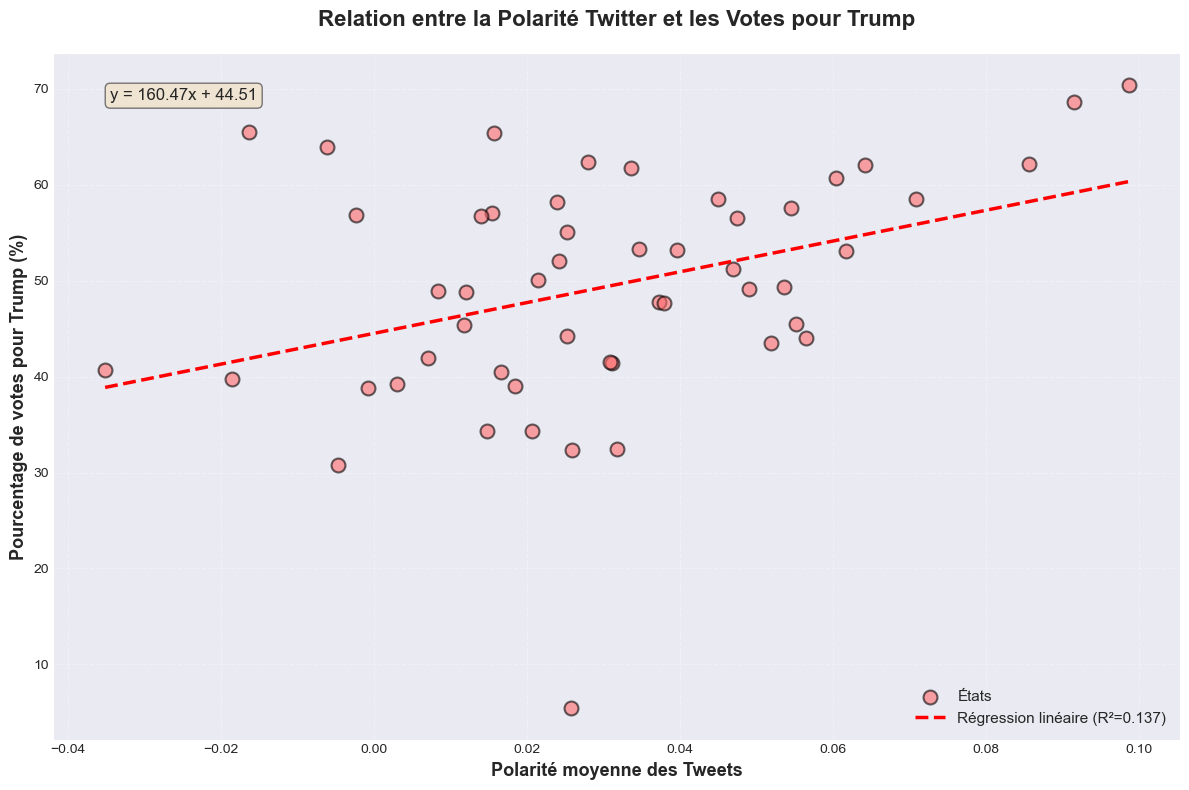


📊 Génération du scatterplot pour Biden...


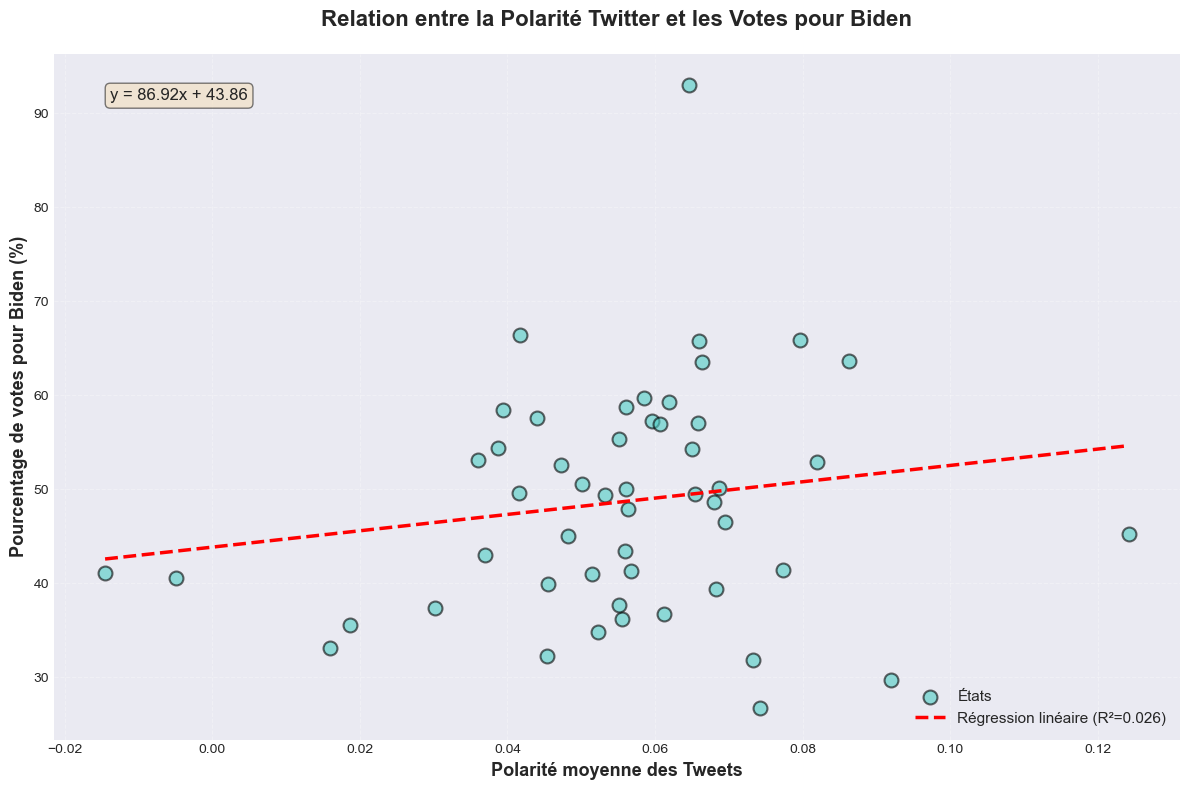


✅ Scatterplots générés avec succès!


In [32]:
def scatterplot(x, y, x_label, y_label, title, color='blue', candidate_name=''):
    """
    Crée un scatterplot avec la droite de régression linéaire
    
    Paramètres:
    - x: variable indépendante (polarité)
    - y: variable dépendante (pourcentage de votes)
    - x_label: label de l'axe x
    - y_label: label de l'axe y
    - title: titre du graphique
    - color: couleur des points
    - candidate_name: nom du candidat pour la légende
    """
    # Supprimer les NaN
    mask = ~(pd.isna(x) | pd.isna(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # Appliquer la régression
    m, b, r2 = linear_regression(x_clean.values, y_clean.values)
    
    # Créer la figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Scatterplot
    ax.scatter(x_clean, y_clean, alpha=0.6, s=100, color=color, edgecolors='black', linewidth=1.5, label='États')
    
    # Droite de régression
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_line = m * x_line + b
    ax.plot(x_line, y_line, 'r--', linewidth=2.5, label=f'Régression linéaire (R²={r2:.3f})')
    
    # Annotations
    ax.set_xlabel(x_label, fontsize=13, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    # Équation sur le graphique
    equation_text = f'y = {m:.2f}x + {b:.2f}'
    ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, 
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Grille et légende
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    return m, b, r2

# Générer les scatterplots pour Trump et Biden
print("=" * 70)
print("VISUALISATION: POLARITÉ vs POURCENTAGE DE VOTES")
print("=" * 70)

print("\n📊 Génération du scatterplot pour Trump...")
m_trump_plot, b_trump_plot, r2_trump_plot = scatterplot(
    trump_merged['mean_polarity'],
    trump_merged['trump_pct'],
    x_label='Polarité moyenne des Tweets',
    y_label='Pourcentage de votes pour Trump (%)',
    title='Relation entre la Polarité Twitter et les Votes pour Trump',
    color='#FF6B6B',
    candidate_name='Trump'
)

print("\n📊 Génération du scatterplot pour Biden...")
m_biden_plot, b_biden_plot, r2_biden_plot = scatterplot(
    biden_merged['mean_polarity'],
    biden_merged['biden_pct'],
    x_label='Polarité moyenne des Tweets',
    y_label='Pourcentage de votes pour Biden (%)',
    title='Relation entre la Polarité Twitter et les Votes pour Biden',
    color='#4ECDC4',
    candidate_name='Biden'
)

print("\n" + "=" * 70)
print("✅ Scatterplots générés avec succès!")
print("=" * 70)

### Étape 15 : Fonctions d'analyse gagnant/perdant

Créer trois fonctions pour analyser les polarités selon les résultats de vote :
- `WinnerPolarity` : polarités dans les États gagnés
- `LoserPolarity` : polarités dans les États perdus  
- `GetPolarities` : calcule la moyenne ou l'écart-type


In [33]:
def GetPolarities(df_merged, candidate_name, func='mean'):
    """
    Calcule la polarité moyenne ou l'écart-type des tweets pour les États gagnés et perdus.
    
    Paramètres:
    - df_merged: DataFrame avec données de polarité et résultats électoraux
    - candidate_name: 'Trump' ou 'Biden'
    - func: 'mean' pour moyenne ou 'std' pour écart-type
    
    Retour:
    - Dictionnaire {'winner': valeur_gagnés, 'loser': valeur_perdus}
    """
    if candidate_name == 'Trump':
        winner_col = 'trump_win'
    else:
        winner_col = 'biden_win'
    
    # Séparer les États gagnés et perdus
    winner_states = df_merged[df_merged[winner_col] == True]
    loser_states = df_merged[df_merged[winner_col] == False]
    
    # Calculer la statistique demandée
    if func == 'mean':
        winner_val = winner_states['mean_polarity'].mean()
        loser_val = loser_states['mean_polarity'].mean()
    elif func == 'std':
        winner_val = winner_states['mean_polarity'].std()
        loser_val = loser_states['mean_polarity'].std()
    else:
        raise ValueError("func doit être 'mean' ou 'std'")
    
    return {'winner': winner_val, 'loser': loser_val}


def getLoserWinnerPolarities(df_merged, candidate_name):
    """
    Affiche les polarités moyennes et écarts-types pour les États gagnés et perdus.
    
    Paramètres:
    - df_merged: DataFrame fusionné
    - candidate_name: 'Trump' ou 'Biden'
    """
    print(f"\n{'='*70}")
    print(f"📊 ANALYSE GAGNANTS vs PERDANTS - {candidate_name.upper()}")
    print(f"{'='*70}")
    
    if candidate_name == 'Trump':
        winner_col = 'trump_win'
    else:
        winner_col = 'biden_win'
    
    # Séparer gagnés/perdus
    winner_polarities = df_merged[df_merged[winner_col] == True]['mean_polarity']
    loser_polarities = df_merged[df_merged[winner_col] == False]['mean_polarity']
    
    print(f"\n{candidate_name} - États GAGNÉS:")
    print(f"   Nombre d'États: {len(winner_polarities)}")
    print(f"   Polarité moyenne: {winner_polarities.mean():.4f}")
    print(f"   Écart-type: {np.std(winner_polarities):.4f}")
    
    print(f"\n{candidate_name} - États PERDUS:")
    print(f"   Nombre d'États: {len(loser_polarities)}")
    print(f"   Polarité moyenne: {loser_polarities.mean():.4f}")
    print(f"   Écart-type: {np.std(loser_polarities):.4f}")
    
    return winner_polarities, loser_polarities

# Test des fonctions
print("Test des fonctions GetPolarities et getLoserWinnerPolarities:\n")

# Test Trump
trump_winner_pol, trump_loser_pol = getLoserWinnerPolarities(trump_merged, 'Trump')

print(f"\nVérification avec GetPolarities (Trump):")
print(f"   Moyenne - Gagnés: {trump_winner_pol.mean():.4f} | Perdus: {trump_loser_pol.mean():.4f}")
print(f"   Écart-type: {np.std(trump_winner_pol):.4f}")

trump_stats_mean = GetPolarities(trump_merged, 'Trump', 'mean')
trump_stats_std = GetPolarities(trump_merged, 'Trump', 'std')

print(f"\nRésumé Trump:")
print(f"   Moyenne - Gagnés: {trump_stats_mean['winner']:.4f} | Perdus: {trump_stats_mean['loser']:.4f}")
print(f"   Écart-type - Gagnés: {trump_stats_std['winner']:.4f} | Perdus: {trump_stats_std['loser']:.4f}")

# Test Biden
biden_winner_pol, biden_loser_pol = getLoserWinnerPolarities(biden_merged, 'Biden')

print(f"\nVérification avec GetPolarities (Biden):")
print(f"   Moyenne - Gagnés: {biden_winner_pol.mean():.4f} | Perdus: {biden_loser_pol.mean():.4f}")
print(f"   Écart-type: {np.std(biden_loser_pol):.4f}")

biden_stats_mean = GetPolarities(biden_merged, 'Biden', 'mean')
biden_stats_std = GetPolarities(biden_merged, 'Biden', 'std')

print(f"\nRésumé Biden:")
print(f"   Moyenne - Gagnés: {biden_stats_mean['winner']:.4f} | Perdus: {biden_stats_mean['loser']:.4f}")
print(f"   Écart-type - Gagnés: {biden_stats_std['winner']:.4f} | Perdus: {biden_stats_std['loser']:.4f}")

Test des fonctions GetPolarities et getLoserWinnerPolarities:


📊 ANALYSE GAGNANTS vs PERDANTS - TRUMP

Trump - États GAGNÉS:
   Nombre d'États: 25
   Polarité moyenne: 0.0391
   Écart-type: 0.0291

Trump - États PERDUS:
   Nombre d'États: 26
   Polarité moyenne: 0.0218
   Écart-type: 0.0223

Vérification avec GetPolarities (Trump):
   Moyenne - Gagnés: 0.0391 | Perdus: 0.0218
   Écart-type: 0.0291

Résumé Trump:
   Moyenne - Gagnés: 0.0391 | Perdus: 0.0218
   Écart-type - Gagnés: 0.0297 | Perdus: 0.0227

📊 ANALYSE GAGNANTS vs PERDANTS - BIDEN

Biden - États GAGNÉS:
   Nombre d'États: 26
   Polarité moyenne: 0.0581
   Écart-type: 0.0131

Biden - États PERDUS:
   Nombre d'États: 25
   Polarité moyenne: 0.0525
   Écart-type: 0.0285

Vérification avec GetPolarities (Biden):
   Moyenne - Gagnés: 0.0581 | Perdus: 0.0525
   Écart-type: 0.0285

Résumé Biden:
   Moyenne - Gagnés: 0.0581 | Perdus: 0.0525
   Écart-type - Gagnés: 0.0134 | Perdus: 0.0291


### Étape 16 : Fonction showBarChart

Création d'une fonction pour afficher un diagramme en barres comparant la polarité moyenne des Tweets dans les États gagnés vs perdus, avec barres d'erreur représentant l'écart-type.



🎯 Génération du diagramme en barres comparatif...


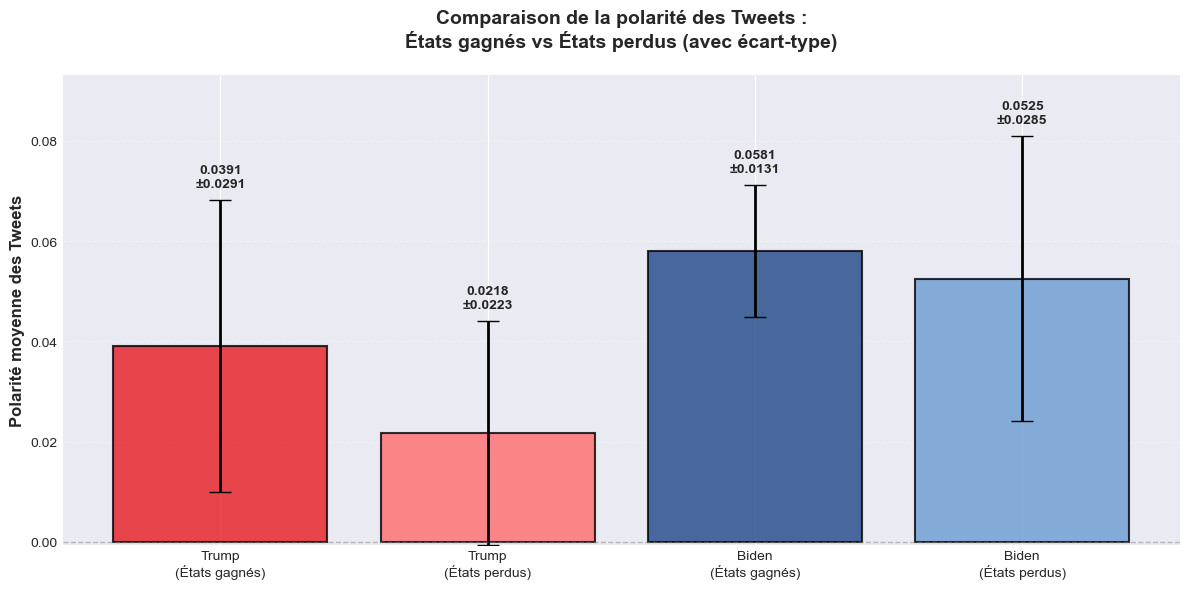


RÉSUMÉ : POLARITÉ MOYENNE PAR RÉSULTAT DE VOTE

Candidat        Type                 Moyenne      Écart-type   N États   
--------------------------------------------------------------------------------
Trump           États gagnés              0.0391      0.0291        25
Trump           États perdus              0.0218      0.0223        26
Biden           États gagnés              0.0581      0.0131        26
Biden           États perdus              0.0525      0.0285        25

📊 ANALYSE DES DIFFÉRENCES :
   • Trump: Différence gagnés-perdus = +0.0173
   • Biden: Différence gagnés-perdus = +0.0055
   → Les Tweets sur Trump sont plus positive dans les États qu'il a gagnés

✅ Graphique généré avec succès!


In [34]:
def showBarChart(df_trump, df_biden):
    """
    Affiche un diagramme en barres comparant les polarités moyennes dans les États gagnés/perdus
    pour Trump et Biden, avec barres d'erreur (écart-type)
    
    Paramètres:
    - df_trump: DataFrame fusionné de Trump (trump_merged)
    - df_biden: DataFrame fusionné de Biden (biden_merged)
    """
    # Calculer les statistiques pour Trump
    trump_winner_pol = df_trump[df_trump['trump_win'] == True]['mean_polarity'].values
    trump_loser_pol = df_trump[df_trump['trump_win'] == False]['mean_polarity'].values
    
    trump_winner_mean = np.mean(trump_winner_pol) if len(trump_winner_pol) > 0 else 0
    trump_loser_mean = np.mean(trump_loser_pol) if len(trump_loser_pol) > 0 else 0
    trump_winner_std = np.std(trump_winner_pol) if len(trump_winner_pol) > 0 else 0
    trump_loser_std = np.std(trump_loser_pol) if len(trump_loser_pol) > 0 else 0
    
    # Calculer les statistiques pour Biden
    biden_winner_pol = df_biden[df_biden['biden_win'] == True]['mean_polarity'].values
    biden_loser_pol = df_biden[df_biden['biden_win'] == False]['mean_polarity'].values
    
    biden_winner_mean = np.mean(biden_winner_pol) if len(biden_winner_pol) > 0 else 0
    biden_loser_mean = np.mean(biden_loser_pol) if len(biden_loser_pol) > 0 else 0
    biden_winner_std = np.std(biden_winner_pol) if len(biden_winner_pol) > 0 else 0
    biden_loser_std = np.std(biden_loser_pol) if len(biden_loser_pol) > 0 else 0
    
    # Configuration du graphique
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Données pour le graphique
    categories = ['Trump\n(États gagnés)', 'Trump\n(États perdus)', 
                  'Biden\n(États gagnés)', 'Biden\n(États perdus)']
    means = [trump_winner_mean, trump_loser_mean, biden_winner_mean, biden_loser_mean]
    stds = [trump_winner_std, trump_loser_std, biden_winner_std, biden_loser_std]
    colors = ['#E81B23', '#FF6B6B', '#1F4788', '#6B9BD1']
    
    # Création du graphique en barres avec barres d'erreur
    bars = ax.bar(categories, means, yerr=stds, capsize=8, color=colors, 
                   alpha=0.8, edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2, 'ecolor': 'black'})
    
    # Ajouter les valeurs sur les barres
    for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std + 0.002,
                f'{mean:.4f}\n±{std:.4f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Mise en forme
    ax.set_ylabel('Polarité moyenne des Tweets', fontsize=12, fontweight='bold')
    ax.set_title('Comparaison de la polarité des Tweets :\nÉtats gagnés vs États perdus (avec écart-type)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Ajuster les limites de l'axe y pour mieux voir les barres d'erreur
    y_max = max([m + s for m, s in zip(means, stds)]) * 1.15
    y_min = min([m - s for m, s in zip(means, stds)]) * 1.15
    ax.set_ylim([y_min, y_max])
    
    plt.tight_layout()
    plt.show()
    
    # Afficher un résumé textuel
    print("\n" + "=" * 80)
    print("RÉSUMÉ : POLARITÉ MOYENNE PAR RÉSULTAT DE VOTE")
    print("=" * 80)
    print(f"\n{'Candidat':<15} {'Type':<20} {'Moyenne':<12} {'Écart-type':<12} {'N États':<10}")
    print("-" * 80)
    print(f"{'Trump':<15} {'États gagnés':<20} {trump_winner_mean:>11.4f} {trump_winner_std:>11.4f} {len(trump_winner_pol):>9}")
    print(f"{'Trump':<15} {'États perdus':<20} {trump_loser_mean:>11.4f} {trump_loser_std:>11.4f} {len(trump_loser_pol):>9}")
    print(f"{'Biden':<15} {'États gagnés':<20} {biden_winner_mean:>11.4f} {biden_winner_std:>11.4f} {len(biden_winner_pol):>9}")
    print(f"{'Biden':<15} {'États perdus':<20} {biden_loser_mean:>11.4f} {biden_loser_std:>11.4f} {len(biden_loser_pol):>9}")
    print("=" * 80)
    
    # Analyse des différences
    trump_diff = trump_winner_mean - trump_loser_mean
    biden_diff = biden_winner_mean - biden_loser_mean
    
    print(f"\n📊 ANALYSE DES DIFFÉRENCES :")
    print(f"   • Trump: Différence gagnés-perdus = {trump_diff:+.4f}")
    print(f"   • Biden: Différence gagnés-perdus = {biden_diff:+.4f}")
    
    if abs(trump_diff) > 0.01:
        direction = "plus positive" if trump_diff > 0 else "plus négative"
        print(f"   → Les Tweets sur Trump sont {direction} dans les États qu'il a gagnés")
    
    if abs(biden_diff) > 0.01:
        direction = "plus positive" if biden_diff > 0 else "plus négative"
        print(f"   → Les Tweets sur Biden sont {direction} dans les États qu'il a gagnés")
    print("=" * 80)


# Afficher le graphique comparatif
print("\n🎯 Génération du diagramme en barres comparatif...")
showBarChart(trump_merged, biden_merged)
print("\n✅ Graphique généré avec succès!")

---

## OBJECTIF 3 - CARTES CHOROPLÈTHES

Création de visualisations géographiques pour représenter les données de sentiment Twitter et les résultats de vote par État sur des cartes des États-Unis.

### Étape 17 : Chargement du shapefile des États américains

Nous chargeons le fichier shapefile contenant les contours géographiques des États américains et retirons l'Alaska et Hawaii pour une meilleure visualisation.

In [35]:
import geopandas as gpd
import zipfile
from shapely.geometry import Point, Polygon

# Charger le shapefile depuis le fichier zip
zip_path = 'data/cb_2018_us_state_500k.zip'
with zipfile.ZipFile(zip_path) as z:
    # Trouver le fichier .shp dans le zip
    shp_file = [name for name in z.namelist() if name.endswith('.shp')][0]
    
    # Geopandas peut lire directement depuis le zip
    gdf_states = gpd.read_file(f'zip://{zip_path}!{shp_file}')

print("=" * 70)
print("CHARGEMENT DU SHAPEFILE DES ÉTATS AMÉRICAINS")
print("=" * 70)
print(f"\nNombre d'États/territoires avant filtrage: {len(gdf_states)}")
print(f"Colonnes disponibles: {list(gdf_states.columns)}")

# Afficher un aperçu
print("\nAperçu des données:")
print(gdf_states[['STUSPS', 'NAME']].head(10))

# Retirer l'Alaska (AK) et Hawaii (HI) pour une meilleure visualisation
gdf_states = gdf_states[~gdf_states['STUSPS'].isin(['AK', 'HI'])]

print(f"\nNombre d'États après retrait de l'Alaska et Hawaii: {len(gdf_states)}")
print("\n✅ Shapefile chargé et filtré avec succès!")
print("=" * 70)

CHARGEMENT DU SHAPEFILE DES ÉTATS AMÉRICAINS

Nombre d'États/territoires avant filtrage: 56
Colonnes disponibles: ['STATEFP', 'STATENS', 'AFFGEOID', 'GEOID', 'STUSPS', 'NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']

Aperçu des données:
  STUSPS            NAME
0     MS     Mississippi
1     NC  North Carolina
2     OK        Oklahoma
3     VA        Virginia
4     WV   West Virginia
5     LA       Louisiana
6     MI        Michigan
7     MA   Massachusetts
8     ID           Idaho
9     FL         Florida

Nombre d'États après retrait de l'Alaska et Hawaii: 54

✅ Shapefile chargé et filtré avec succès!


### Étape 18 : Calcul de la subjectivité moyenne par État

Calcul de la subjectivité moyenne des Tweets pour chaque État, similaire au calcul de la polarité moyenne effectué à l'étape 10.

In [36]:
# Calculer la subjectivité moyenne par État pour Trump
trump_subjectivity_by_state = df_trump.groupby('state_code')['subjectivity'].mean().reset_index()
trump_subjectivity_by_state.columns = ['state_code', 'mean_subjectivity']

# Calculer la subjectivité moyenne par État pour Biden
biden_subjectivity_by_state = df_biden.groupby('state_code')['subjectivity'].mean().reset_index()
biden_subjectivity_by_state.columns = ['state_code', 'mean_subjectivity']

print("=" * 70)
print("SUBJECTIVITÉ MOYENNE PAR ÉTAT")
print("=" * 70)

print("\n📊 TRUMP - Top 5 États avec la plus haute subjectivité:")
print(trump_subjectivity_by_state.sort_values('mean_subjectivity', ascending=False).head())

print("\n📊 BIDEN - Top 5 États avec la plus haute subjectivité:")
print(biden_subjectivity_by_state.sort_values('mean_subjectivity', ascending=False).head())

print("\n📈 Statistiques globales:")
print(f"Trump - Moyenne: {trump_subjectivity_by_state['mean_subjectivity'].mean():.4f}, "
      f"Min: {trump_subjectivity_by_state['mean_subjectivity'].min():.4f}, "
      f"Max: {trump_subjectivity_by_state['mean_subjectivity'].max():.4f}")
print(f"Biden - Moyenne: {biden_subjectivity_by_state['mean_subjectivity'].mean():.4f}, "
      f"Min: {biden_subjectivity_by_state['mean_subjectivity'].min():.4f}, "
      f"Max: {biden_subjectivity_by_state['mean_subjectivity'].max():.4f}")

print("\n✅ Subjectivité moyenne calculée pour tous les États!")
print("=" * 70)

SUBJECTIVITÉ MOYENNE PAR ÉTAT

📊 TRUMP - Top 5 États avec la plus haute subjectivité:
   state_code  mean_subjectivity
12         GU           1.000000
0                       0.425000
52         WV           0.396885
2          AL           0.388540
49         VT           0.384267

📊 BIDEN - Top 5 États avec la plus haute subjectivité:
   state_code  mean_subjectivity
27         MP           0.700000
0                       0.590816
28         MS           0.421761
45         SD           0.419489
9          DE           0.373384

📈 Statistiques globales:
Trump - Moyenne: 0.3492, Min: 0.2506, Max: 1.0000
Biden - Moyenne: 0.3319, Min: 0.0000, Max: 0.7000

✅ Subjectivité moyenne calculée pour tous les États!


### Étape 19 : Fusion des données avec le shapefile

Nous fusionnons les données de polarité, subjectivité et résultats de vote avec les géométries des États pour permettre la création de cartes choroplèthes.

In [37]:
# Charger les données de vote
vote_data = pd.read_csv('data/ap_votes.csv')

# Préparer les données pour Trump
trump_map_data = trump_polarity_by_state.reset_index()
trump_map_data = trump_map_data.merge(trump_subjectivity_by_state, on='state_code', how='inner')
trump_map_data = trump_map_data.merge(vote_data[['state_abr', 'trump_pct', 'trump_win', 'state']], 
                                       left_on='state_code', right_on='state_abr', how='inner')

# Préparer les données pour Biden
biden_map_data = biden_polarity_by_state.reset_index()
biden_map_data = biden_map_data.merge(biden_subjectivity_by_state, on='state_code', how='inner')
biden_map_data = biden_map_data.merge(vote_data[['state_abr', 'biden_pct', 'biden_win', 'state']], 
                                       left_on='state_code', right_on='state_abr', how='inner')

# Fusionner avec le shapefile pour Trump
gdf_trump = gdf_states.merge(trump_map_data, left_on='STUSPS', right_on='state_code', how='left')

# Fusionner avec le shapefile pour Biden
gdf_biden = gdf_states.merge(biden_map_data, left_on='STUSPS', right_on='state_code', how='left')

print("=" * 70)
print("FUSION DES DONNÉES AVEC LE SHAPEFILE")
print("=" * 70)

print(f"\n📍 Trump - États avec données complètes: {gdf_trump['mean_polarity'].notna().sum()}/{len(gdf_trump)}")
print(f"📍 Biden - États avec données complètes: {gdf_biden['mean_polarity'].notna().sum()}/{len(gdf_biden)}")

print("\n📊 Aperçu des données fusionnées (Trump):")
print(gdf_trump[['STUSPS', 'NAME', 'mean_polarity', 'mean_subjectivity', 'trump_pct', 'trump_win']].head())

print("\n✅ Données fusionnées avec succès!")
print("=" * 70)

FUSION DES DONNÉES AVEC LE SHAPEFILE

📍 Trump - États avec données complètes: 49/54
📍 Biden - États avec données complètes: 49/54

📊 Aperçu des données fusionnées (Trump):
  STUSPS            NAME  mean_polarity  mean_subjectivity  trump_pct  \
0     MS     Mississippi       0.054550           0.363412       57.6   
1     NC  North Carolina       0.021443           0.339966       50.1   
2     OK        Oklahoma       0.015691           0.349155       65.4   
3     VA        Virginia       0.025230           0.319848       44.2   
4     WV   West Virginia       0.091442           0.396885       68.6   

   trump_win  
0        1.0  
1        1.0  
2        1.0  
3        0.0  
4        1.0  

✅ Données fusionnées avec succès!


### Étape 20 : Fonction pour créer des cartes choroplèthes

Création d'une fonction générique pour générer des cartes choroplèthes colorées selon différentes variables (polarité, subjectivité, pourcentage de vote, etc.).

🗺️ Génération d'une carte de test...


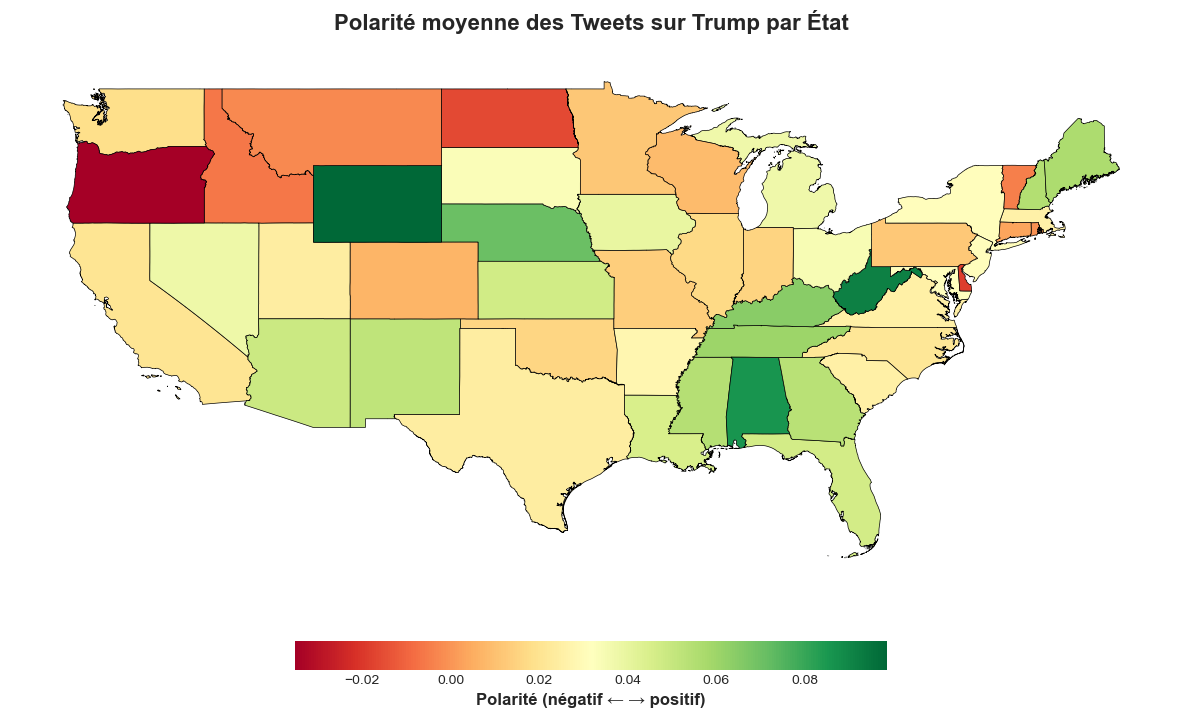

In [38]:
def create_choropleth(gdf, column, title, cmap='RdYlGn', legend_label='Valeur'):
    """
    Crée une carte choroplèthe pour visualiser une variable par État américain.
    
    Paramètres :
    - gdf : GeoDataFrame contenant les données géospatiales
    - column : nom de la colonne à visualiser
    - title : titre de la carte
    - cmap : colormap matplotlib (par défaut 'RdYlGn')
    - legend_label : label de la légende
    """
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))

    # Définir l'échelle partagée pour améliorer la lisibilité
    values = gdf[column].dropna()
    vmin, vmax = values.min(), values.max()

    # Tracer la carte principale sans légende automatique
    gdf.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        edgecolor='black',
        linewidth=0.5,
        legend=False,
        vmin=vmin,
        vmax=vmax
    )

    # Construire manuellement la barre de couleur pour mieux la positionner
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation='horizontal',
        fraction=0.04,
        pad=0.08
    )
    cbar.set_label(legend_label, fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

    # Personnalisation
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')

    # Ajuster les marges pour éviter que la carte ne chevauche la légende
    fig.subplots_adjust(bottom=0.18, top=0.92)

    return fig, ax

# Test de la fonction
if 'gdf_trump' in globals():
    print("🗺️ Génération d'une carte de test...")
    create_choropleth(
        gdf_trump,
        'mean_polarity',
        'Polarité moyenne des Tweets sur Trump par État',
        cmap='RdYlGn',
        legend_label='Polarité (négatif ← → positif)'
    )
    plt.show()
else:
    print("ℹ️ Données non chargées dans cet environnement : exécutez la cellule de fusion avant de générer la carte de test.")

### Étape 21 : Fonction pour comparer deux cartes côte-à-côte

Création d'une fonction pour afficher deux cartes choroplèthes côte-à-côte, permettant de comparer directement Trump et Biden sur une même variable.


🗺️ COMPARAISON 1: POLARITÉ MOYENNE PAR ÉTAT


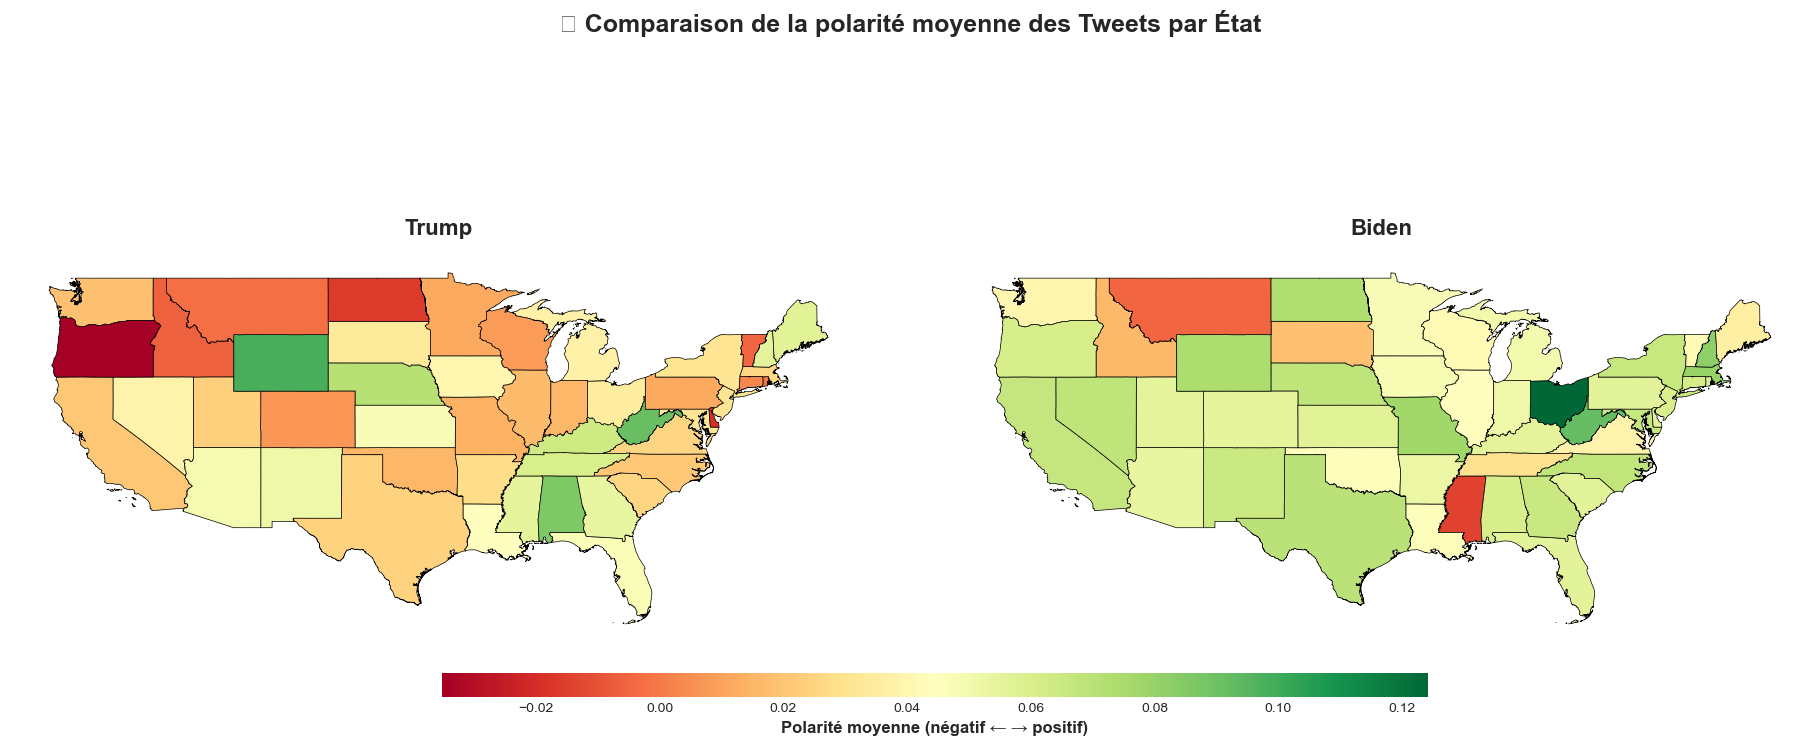


🗺️ COMPARAISON 2: SUBJECTIVITÉ MOYENNE PAR ÉTAT


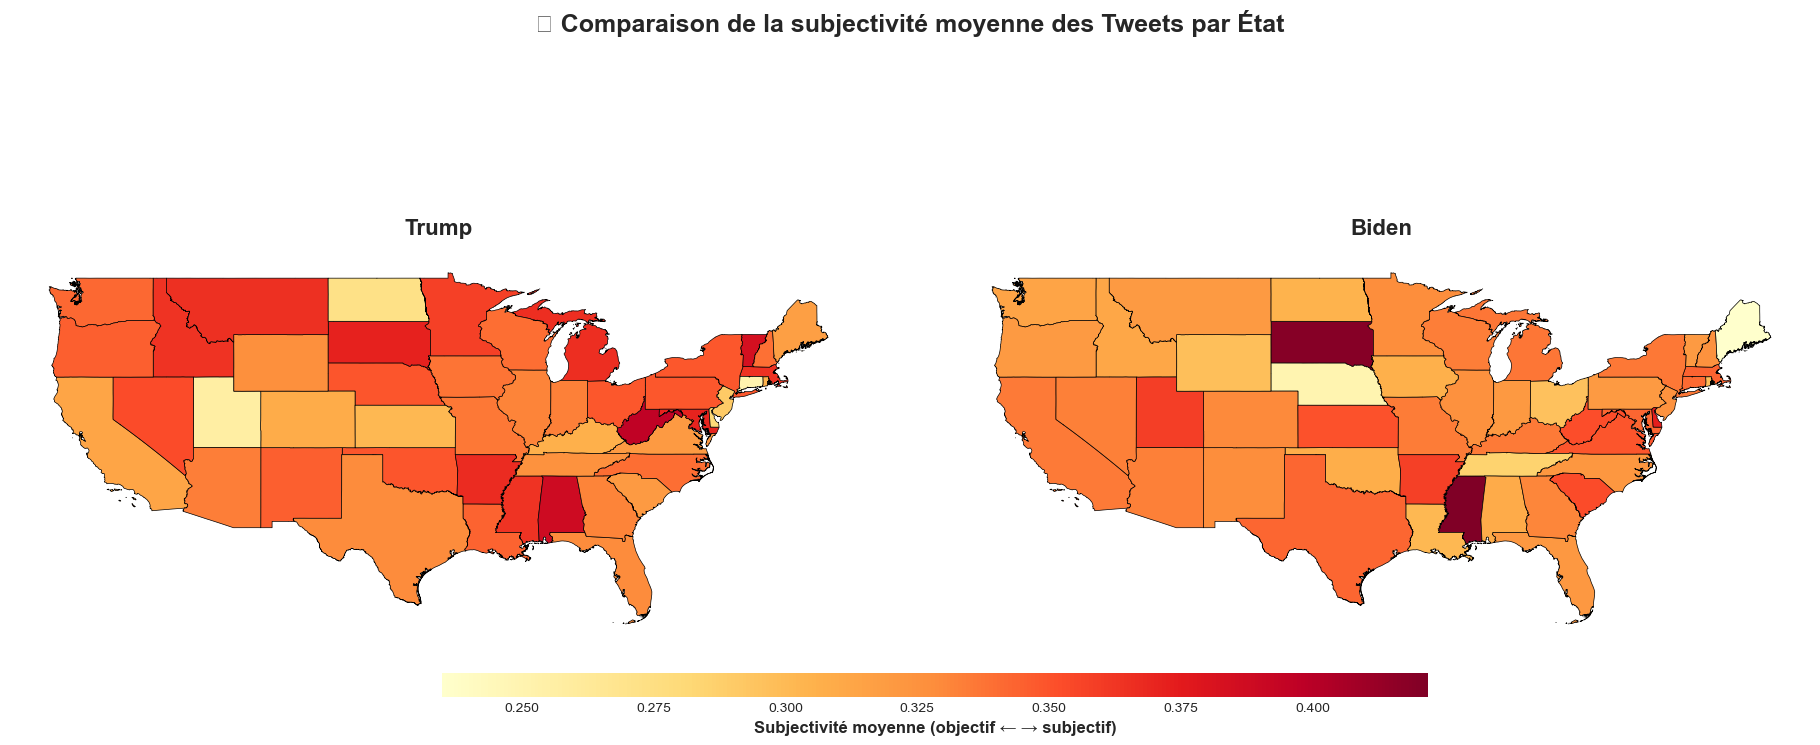


🗺️ COMPARAISON 3: POURCENTAGE DE VOTE PAR ÉTAT


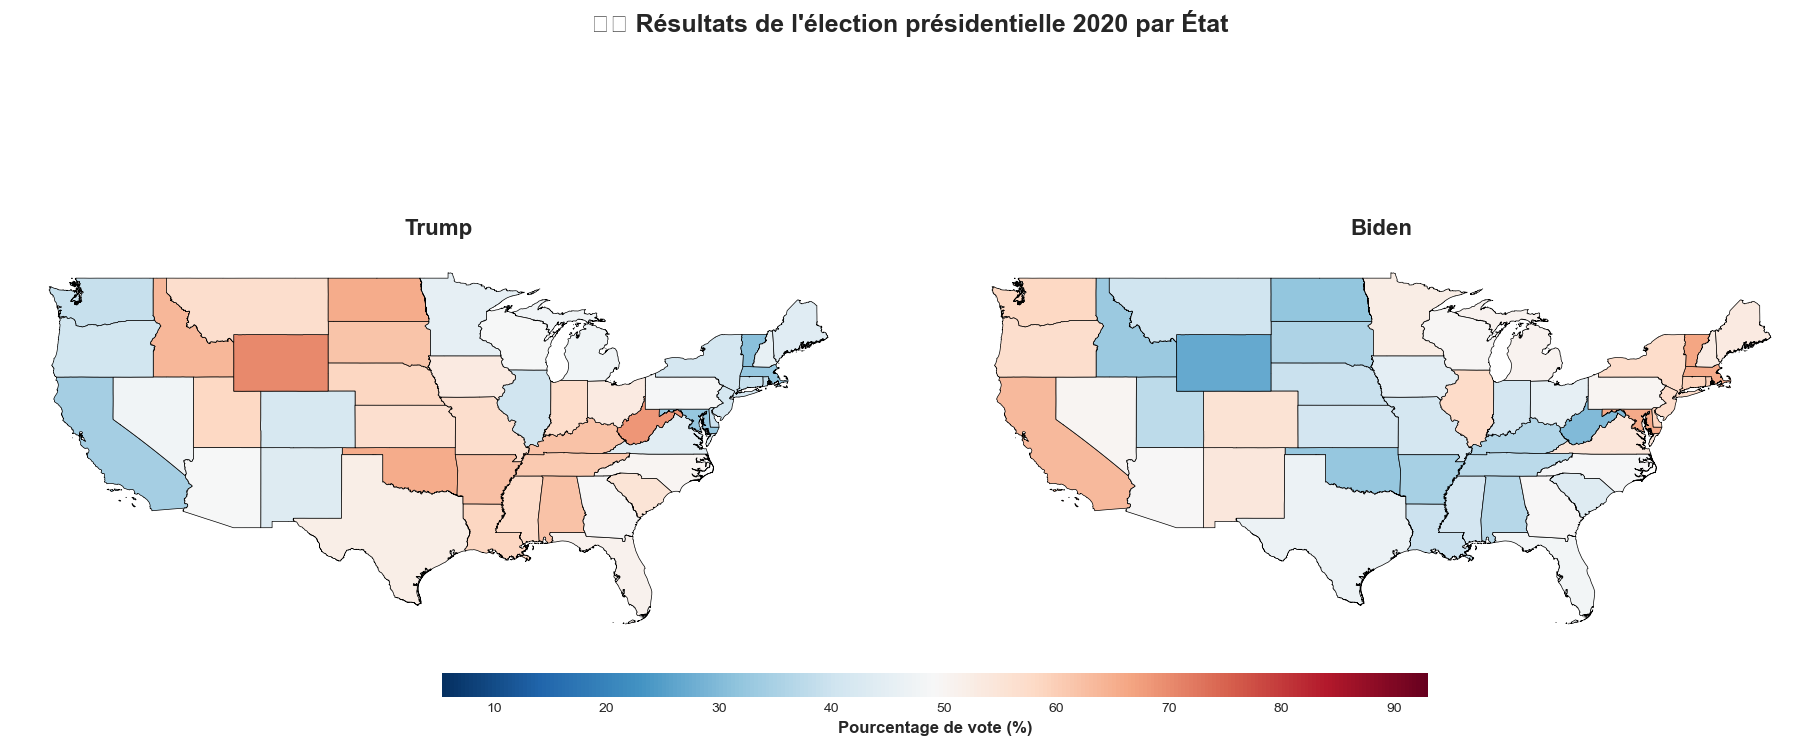

In [39]:
def compare_choropleths(gdf_left, column_left, title_left,
                        gdf_right, column_right, title_right,
                        cmap='RdYlGn', legend_label='Valeur', overall_title=''):
    """
    Compare deux cartes choroplèthes côte-à-côte.
    
    Paramètres :
    - gdf_left : GeoDataFrame pour la carte de gauche
    - column_left : nom de la colonne à visualiser (gauche)
    - title_left : titre de la carte de gauche
    - gdf_right : GeoDataFrame pour la carte de droite
    - column_right : nom de la colonne à visualiser (droite)
    - title_right : titre de la carte de droite
    - cmap : colormap matplotlib
    - legend_label : label de la légende
    - overall_title : titre global pour les deux cartes
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Calculer vmin et vmax communs pour avoir la même échelle
    all_values = pd.concat([
        gdf_left[column_left].dropna(),
        gdf_right[column_right].dropna()
    ])
    vmin, vmax = all_values.min(), all_values.max()

    # Carte de gauche
    gdf_left.plot(
        column=column_left,
        ax=axes[0],
        legend=False,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolor='black',
        linewidth=0.5
    )
    axes[0].set_title(title_left, fontsize=16, fontweight='bold', pad=15)
    axes[0].axis('off')

    # Carte de droite
    gdf_right.plot(
        column=column_right,
        ax=axes[1],
        legend=False,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolor='black',
        linewidth=0.5
    )
    axes[1].set_title(title_right, fontsize=16, fontweight='bold', pad=15)
    axes[1].axis('off')

    # Colorbar commune positionnée sous les cartes
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(
        sm,
        ax=axes,
        orientation='horizontal',
        fraction=0.04,
        pad=0.1,
        aspect=40
    )
    cbar.set_label(legend_label, fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

    # Titre global et ajustement des marges pour éviter le chevauchement
    if overall_title:
        fig.suptitle(overall_title, fontsize=18, fontweight='bold', y=0.97)

    fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.18, wspace=0.1)

# Test de la fonction avec les trois comparaisons demandées
if 'gdf_trump' in globals() and 'gdf_biden' in globals():
    # Test 1: Comparaison de polarité
    print("\n" + "=" * 70)
    print("🗺️ COMPARAISON 1: POLARITÉ MOYENNE PAR ÉTAT")
    print("=" * 70)
    compare_choropleths(
        gdf_trump, 'mean_polarity', 'Trump',
        gdf_biden, 'mean_polarity', 'Biden',
        cmap='RdYlGn',
        legend_label='Polarité moyenne (négatif ← → positif)',
        overall_title='📊 Comparaison de la polarité moyenne des Tweets par État'
    )
    plt.show()

    # Test 2: Comparaison de subjectivité
    print("\n" + "=" * 70)
    print("🗺️ COMPARAISON 2: SUBJECTIVITÉ MOYENNE PAR ÉTAT")
    print("=" * 70)
    compare_choropleths(
        gdf_trump, 'mean_subjectivity', 'Trump',
        gdf_biden, 'mean_subjectivity', 'Biden',
        cmap='YlOrRd',
        legend_label='Subjectivité moyenne (objectif ← → subjectif)',
        overall_title='💭 Comparaison de la subjectivité moyenne des Tweets par État'
    )
    plt.show()

    # Test 3: Comparaison des pourcentages de vote
    print("\n" + "=" * 70)
    print("🗺️ COMPARAISON 3: POURCENTAGE DE VOTE PAR ÉTAT")
    print("=" * 70)
    compare_choropleths(
        gdf_trump, 'trump_pct', 'Trump',
        gdf_biden, 'biden_pct', 'Biden',
        cmap='RdBu_r',
        legend_label='Pourcentage de vote (%)',
        overall_title='🗳️ Résultats de l\'élection présidentielle 2020 par État'
    )
    plt.show()

    plt.style.use('default')
else:
    print("ℹ️ Données non chargées : exécutez les cellules de fusion des données avant d'utiliser cette fonction.")